# 14 - Explainability suite

Explainability tools are essential when working with modern machine-learning models like XGBoost, which are highly predictive but not naturally interpretable. They allow us to understand which features drive predictions, detect sources of bias, verify that the model aligns with real-world causal structure, and communicate insights transparently. In Chapter 1, explainability is applied primarily to the salary model, because this model underpins fairness analysis, competitiveness scoring, and several downstream analytic layers.

**SHAP** (SHapley Additive exPlanations) provides the mathematical backbone of the explainability suite. Built on cooperative game theory, SHAP attributes a model’s prediction to individual features by computing each feature’s marginal contribution across all possible subsets of features. This provides globally consistent feature importance, clear directional effects, interaction detection, and local case-by-case explanations. SHAP is the most expressive and diagnostically rich tool in the suite, and in this project it reveals how job characteristics, seniority, domain, and skill PCs contribute to predicted salary levels.

Partial Dependence Plots (**PDPs**) complement SHAP by showing the average marginal effect of a single feature on predictions. By varying one feature while averaging over all others, PDPs reveal whether the relationship with salary is linear, monotonic, U-shaped, or shows diminishing returns. Although PDPs assume feature independence—an approximation—they are still valuable for high-level trend interpretation.

Individual Conditional Expectation (**ICE**) curves deepen this view by showing the feature effect separately for each job. Where PDPs provide the population average, ICE curves expose heterogeneity: for example, whether a feature benefits some job groups but not others, or whether interactions are present. ICE is often used to diagnose behavioural patterns that PDPs smooth over.

Taken together, SHAP, PDPs, and ICE form a coherent framework: SHAP reveals global and local importance, PDPs show average feature behaviour, and ICE highlights how these behaviours differ across observations. This combination is sufficient to fully characterise the model’s internal decision structure and identify any sources of unfairness or misalignment with domain knowledge.

Finally, these explainability tools are only applied to the salary model, not the 27 skill-requirement models. The skill models are not retained for interpretation; their sole purpose is to generate the skill probability matrix, which is the object of interest for all future skill-related analyses. Attempts to interpret the raw skill models would be misleading due to redundancy, multicollinearity, and the fact that each skill is modelled independently. Instead, skill interactions, geographic patterns, and job-level skill demands are derived directly from the probability matrix in later chapters.

This framework ensures that explainability is focused where it is meaningful and scientifically robust: the salary model, which persists throughout your system, and not the transient machinery used to generate skill probabilities.

## Block 0 - Set up

### Import libraries

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap
import sys
from pathlib import Path
from sklearn.model_selection import train_test_split
import joblib

In [23]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 200)

### Set Path

In [24]:
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))
project_root

PosixPath('/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine')

In [25]:
from src.job_intel.config import (CH1_PROCESSED_SALARY_MODEL_PCA_DF, MODELS_DIR)
OUT_DIR = project_root / "docs/narrative/figures/ch1_explainability"
SALARY_MODEL_PATH = MODELS_DIR / "salary_model_v4.pkl"
PCA_MODEL_PATH = MODELS_DIR/ "skill_pca_v1.pkl"

### Load models

In [26]:
salary_model = joblib.load(SALARY_MODEL_PATH)
pca_model    = joblib.load(PCA_MODEL_PATH)

### Load and prepare data

In [27]:
df_ch0 = pd.read_csv(CH1_PROCESSED_SALARY_MODEL_PCA_DF)
response = df_ch0['sal_mean']
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_rich_code', 
            # Skills
            'skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC4', 'skill_PC5', 
            'skill_PC6', 'skill_PC7', 'skill_PC8', 'skill_PC9', 'skill_PC10'
            ]]

cat_cols = ['size_code','sector_code','state_code','ownership_code',
            'seniority_code','title_rich_code']
features[cat_cols] = features[cat_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(features, response, test_size=0.20, random_state=101)

/var/folders/vx/4t7xz04d6_39xszmh_6hq4br0000gn/T/ipykernel_27393/2866201311.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[cat_cols] = features[cat_cols].astype('category')


### Sanity checks

In [28]:
print(X_train.shape)
print(X_test.shape)
print((X_train.shape[0] + X_test.shape[0]) == len(df_ch0))

(4928, 16)
(1233, 16)
True


In [29]:
X_train.dtypes

size_code          category
sector_code        category
state_code         category
ownership_code     category
seniority_code     category
title_rich_code    category
skill_PC1           float64
skill_PC2           float64
skill_PC3           float64
skill_PC4           float64
skill_PC5           float64
skill_PC6           float64
skill_PC7           float64
skill_PC8           float64
skill_PC9           float64
skill_PC10          float64
dtype: object

In [30]:
X_train.columns

Index(['size_code', 'sector_code', 'state_code', 'ownership_code',
       'seniority_code', 'title_rich_code', 'skill_PC1', 'skill_PC2',
       'skill_PC3', 'skill_PC4', 'skill_PC5', 'skill_PC6', 'skill_PC7',
       'skill_PC8', 'skill_PC9', 'skill_PC10'],
      dtype='object')

In [31]:
print(f"Expected R2 test (from Notebook): 0.30325102236719725\nCurrent R2 test from `salary_model.score(X_test, y_test)`: {salary_model.score(X_test, y_test)}")

Expected R2 test (from Notebook): 0.30325102236719725
Current R2 test from `salary_model.score(X_test, y_test)`: 0.30325102236719725


## Block 1 — SHAP Global
* Initialise SHAP
* Compute SHAP values on full training set
* Global bar plot (mean |SHAP|)
* Global beeswarm plot
* Extract and print top drivers

In [32]:
# Initialise SHAP
explainer = shap.TreeExplainer(salary_model)

In [33]:
# Compute SHAP on training set
shap_values = explainer(X_train)

In [34]:
OUT_DIR = Path("/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/processed/ch5_assets")  # pick your artefacts dir
OUT_DIR.mkdir(parents=True, exist_ok=True)

# shap_values is a shap.Explanation returned by explainer(X_sample)
np.savez_compressed(
    OUT_DIR / "shap_salary_explanation.npz",
    values=shap_values.values.astype(np.float32),
    base_values=shap_values.base_values.astype(np.float32),
    data=shap_values.data.astype(np.float32),
    feature_names=np.array(shap_values.feature_names, dtype="U"),
)

`shap_values` contains the raw, per-observation feature contributions produced by SHAP.
For each row and each feature, the value quantifies how much that feature increases or decreases the model’s predicted salary relative to the model’s baseline (expected) prediction.
Positive values indicate upward pressure on salary predictions, while negative values indicate downward pressure.
For any observation, the sum of all SHAP values plus the baseline equals the model’s predicted salary, making the explanation fully additive and exact.

In [13]:
# Sanity check
shap_values.values.shape == X_train.shape

True

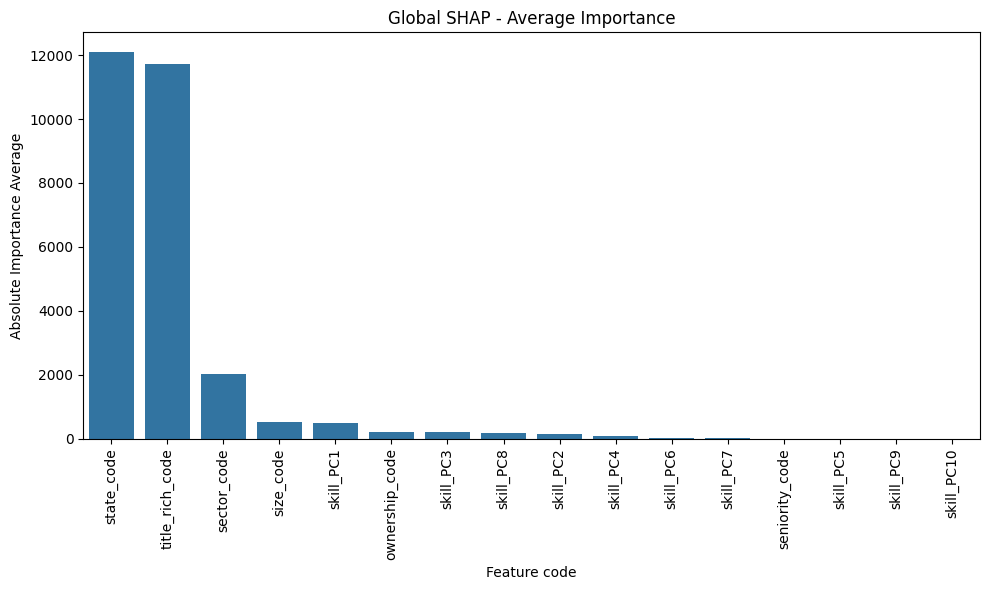

In [16]:
# Global bar plot

global_shap_mean = pd.DataFrame({'features':shap_values.feature_names, 'average':abs(shap_values.values).mean(axis = 0)})
global_shap_mean = global_shap_mean.sort_values(by = 'average', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data = global_shap_mean,
    x = 'features',
    y = 'average'
)
plt.xticks(rotation = 90)
plt.title('Global SHAP - Average Importance')
plt.ylabel('Absolute Importance Average')
plt.xlabel('Feature code')

plt.tight_layout()
plt.savefig(OUT_DIR / "shap_global_bar.png", dpi=300, bbox_inches="tight")

In [18]:
from src.job_intel.config import PROCESSED_DATA_DIR
global_shap_mean.to_csv(PROCESSED_DATA_DIR / 'global_shap_mean.csv', index=False)

In [15]:
global_shap_mean.sort_values('average', ascending=False)

,features,average
2,state_code,12105.803711
5,title_rich_code,11732.526367
1,sector_code,2012.936279
0,size_code,536.011353
6,skill_PC1,482.084015
3,ownership_code,225.165176
8,skill_PC3,217.944244
13,skill_PC8,194.310928
7,skill_PC2,138.981125
9,skill_PC4,91.831268


The global SHAP bar plot shows that structural job attributes dominate salary predictions, with geographic location (`state_code`) and role richness (`title_rich_code`) being the strongest drivers of model behaviour. Industry sector also contributes substantially, while company size and ownership have more moderate effects. Skill-related information, represented through PCA components, has a measurable but smaller overall influence compared to role and location, and its importance is distributed across multiple components rather than concentrated in a single PC. This indicates that skills matter collectively, but structural labour-market factors explain a larger share of salary variation in the model.

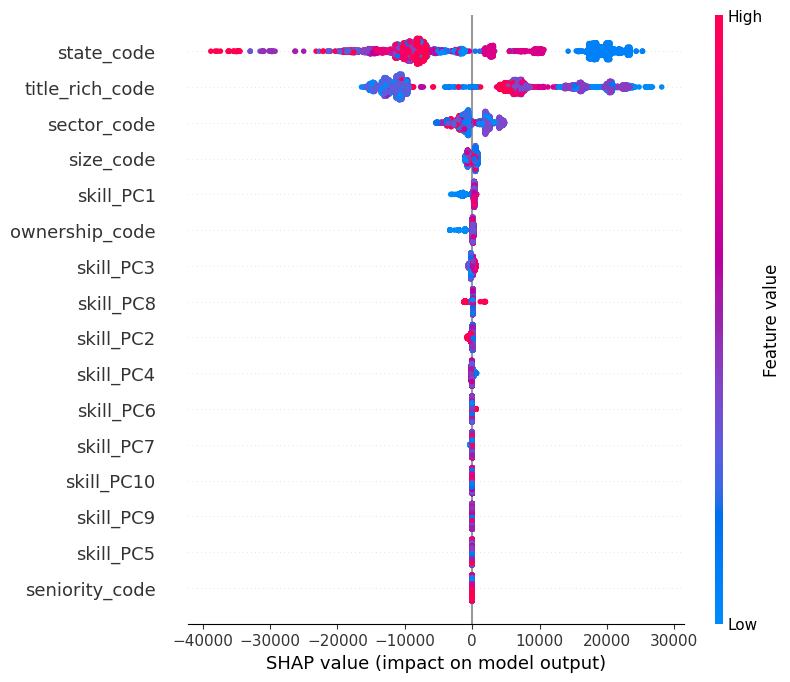

In [16]:
# Global beeswarm plot
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.savefig(OUT_DIR / "shap_global_beeswarm.png", dpi=300, bbox_inches="tight")

##### SHAP Beeswarm Interpretation — Global Salary Drivers

The SHAP beeswarm plot reveals that **geographic location (`state_code`)** and **role richness (`title_rich_code`)** dominate the model’s global behaviour. These features not only rank highest in mean absolute SHAP value, but also display **strong bidirectional effects**, with different categories pushing predicted salaries substantially upward or downward depending on the specific job. The very wide horizontal dispersion of points for these features indicates pronounced **heterogeneity**: location and role semantics do not act as simple linear adjustments, but instead define distinct salary regimes across the labour market.

**Industry sector (`sector_code`)**, **company size (`size_code`)**, and **ownership structure (`ownership_code`)** exhibit more moderate influence. Their SHAP distributions are narrower and more symmetric around zero, suggesting that these variables primarily introduce **systematic contextual shifts** rather than extreme salary deviations. These features function as stabilising structural modifiers, shaping baseline expectations without overwhelming the prediction.

In contrast, the **skill-related PCA components** (e.g. `skill_PC1`, `skill_PC2`, `skill_PC3`) show comparatively smaller magnitudes and tighter clustering around zero. Where directional colour gradients are visible, they indicate that higher skill intensity tends to be associated with modest upward salary adjustments; however, these effects are clearly secondary to those of location and role. The symmetry and limited spread of the skill PCs suggest that skills operate in a **conditional and context-dependent manner**, refining predictions within the structural constraints imposed by geography, role, and industry rather than driving salary outcomes on their own.

Finally, the near-zero contribution of **explicit seniority encoding (`seniority_code`)** implies that seniority information is largely absorbed by richer title representations and correlated structural features. This redundancy indicates effective feature integration rather than a failure of the seniority signal.

Taken together, the beeswarm plot highlights a clear hierarchy in salary determination within the model: **structural labour-market factors establish the dominant salary landscape**, while skills provide incremental differentiation within those regimes. This decomposition motivates the use of PDP and ICE analyses as complementary tools to probe the *shape* and *stability* of these effects, rather than revisiting feature importance itself.


In [17]:
# Extract and print top drivers
global_shap_mean.head(5)

,features,average
2,state_code,12105.803711
5,title_rich_code,11732.526367
1,sector_code,2012.936279
0,size_code,536.011353
6,skill_PC1,482.084015


## Block 2 — SHAP Dependence Plots

In [18]:
skills = [# Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]

loadings = pd.DataFrame(
    pca_model.components_.T,
    index=skills,
    columns=[f"PC{i+1}" for i in range(10)]
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
core_programming__basic,0.423727,-0.124008,0.285786,-0.262649,-0.003284,-0.091759,0.341033,-0.435815,0.247358,-0.292232
core_programming__intermediate,0.139735,-0.102665,-0.014122,0.038017,0.030661,0.038589,0.050609,-0.017441,0.075627,-0.131663
core_programming__advanced,0.001854,-0.003711,0.001158,0.000208,0.000832,0.001625,0.000868,0.002211,0.003578,-0.001169
data_engineering_pipelines__basic,0.007271,0.007022,-0.013100,0.010150,0.000656,0.004248,0.008360,0.007913,0.015081,-0.000478
data_engineering_pipelines__intermediate,0.438001,-0.114083,-0.254168,0.202403,-0.069888,0.273704,-0.096935,0.225777,-0.291864,-0.367351
data_engineering_pipelines__advanced,0.223082,-0.099995,0.018525,0.181114,-0.100865,0.233552,0.038472,-0.239834,0.042394,0.099825
ml_ai__basic,0.145699,-0.120309,0.432614,-0.063083,-0.070631,-0.002067,-0.404033,0.047760,-0.222949,0.059303
ml_ai__intermediate,0.152610,-0.123969,0.415988,-0.115643,-0.050566,-0.051853,-0.415518,0.028178,-0.149255,0.041405
ml_ai__advanced,0.081754,-0.110176,0.208863,-0.006450,-0.039371,0.017795,-0.178220,-0.017534,-0.044040,0.071349
analytics_stats__basic,0.180525,0.289254,0.396368,0.010952,-0.143344,0.302165,0.472641,0.564250,-0.028823,0.185006


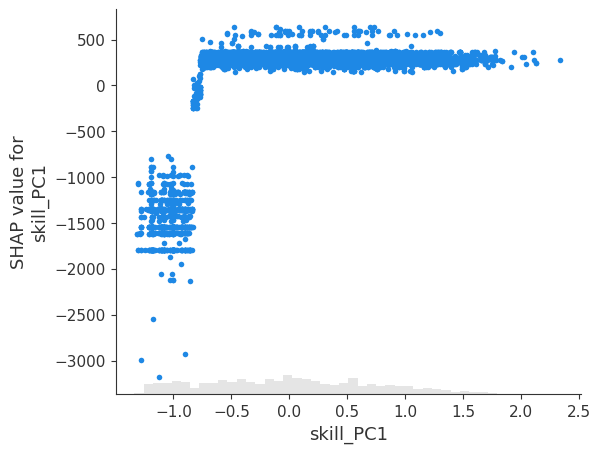

In [19]:
shap.plots.scatter(shap_values[:, "skill_PC1"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC01.png", dpi=300, bbox_inches="tight")

In [20]:
loadings['PC1'].sort_values(ascending=False)

data_engineering_pipelines__intermediate    0.438001
core_programming__basic                     0.423727
db_storage__basic                           0.414585
cloud__basic                                0.317317
db_storage__intermediate                    0.306975
data_engineering_pipelines__advanced        0.223082
analytics_stats__basic                      0.180525
bi_viz__intermediate                        0.177001
productivity_workflow__intermediate         0.156836
ml_ai__intermediate                         0.152610
cloud__intermediate                         0.149984
ml_ai__basic                                0.145699
core_programming__intermediate              0.139735
soft_skills__leadership                     0.093141
ml_ai__advanced                             0.081754
productivity_workflow__basic                0.076742
cloud__advanced                             0.035887
db_storage__advanced                        0.035869
analytics_stats__intermediate               0.

##### Interpretation — Skill_PC1 (PCA loadings + SHAP dependence)

**What PC1 represents (from PCA loadings):**  
PC1 is primarily a *foundational technical infrastructure* axis. The strongest positive loadings are concentrated in **data engineering pipelines** (especially *intermediate* and *advanced*), **database/storage fundamentals** (basic + intermediate), **core programming (basic)**, and **cloud fundamentals**. Secondary positive contributors include **analytics/statistics (basic)** and **ML/AI (basic–intermediate)**. In concrete terms, PC1 is high for roles that emphasise practical “production-adjacent” capabilities such as building/maintaining pipelines, working with databases/storage, and operating in cloud environments—i.e., a baseline technical stack expected in many modern data roles.

**How PC1 affects salary predictions (from SHAP dependence):**  
The dependence plot shows a clear **threshold (tipping point) effect** rather than a smooth linear relationship.  
- **Very low PC1 (≈ ≤ −0.8):** PC1 contributes strongly **negative** SHAP values (large salary penalty). This region represents postings with weak signals of foundational technical stack (e.g., low emphasis on pipelines, databases/storage, core programming, cloud).  
- **Tipping point region (≈ −0.7 to −0.5):** There is a rapid transition from negative to positive contributions, indicating the model has learned a **minimum baseline threshold** of technical foundations that separates lower- from higher-paying job profiles.  
- **Above the threshold (≈ ≥ −0.5):** PC1 contributions become **positive but relatively flat**, suggesting **diminishing returns**: once baseline competence is met, additional increases in this foundational skill bundle provide only modest salary uplift.

**Substantive takeaway:**  
PC1 behaves like a **gatekeeper skill bundle**: lacking core infrastructure skills (pipelines + databases/storage + basic programming + cloud) is strongly associated with lower predicted salaries, but exceeding the minimum threshold does not strongly differentiate salaries. This implies that, in the model, foundational technical competence is necessary to avoid penalty, while higher salary differentiation is driven more by structural factors (role/title richness, location, sector) and potentially by other specialised skill dimensions (captured in other PCs).

**One-sentence summary:**  
*Skill PC1 captures foundational technical infrastructure skills (programming, data engineering pipelines, databases, and cloud), and exhibits a strong gatekeeping threshold: roles lacking this baseline are heavily penalised in salary predictions, while additional proficiency beyond a minimum level yields only modest returns.*



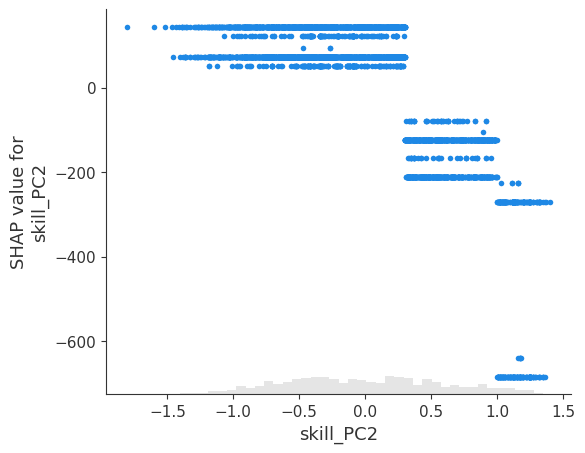

In [21]:
shap.plots.scatter(shap_values[:, "skill_PC2"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC02.png", dpi=300, bbox_inches="tight")

In [22]:
loadings['PC2'].sort_values(ascending=False)

bi_viz__basic                               0.579019
bi_viz__intermediate                        0.465427
soft_skills__leadership                     0.322422
db_storage__basic                           0.297416
analytics_stats__basic                      0.289254
soft_skills__core                           0.201652
domain_specific__none                       0.074556
productivity_workflow__basic                0.051873
db_storage__intermediate                    0.027563
analytics_stats__intermediate               0.024498
productivity_workflow__intermediate         0.017029
bi_viz__advanced                            0.014122
data_engineering_pipelines__basic           0.007022
analytics_stats__advanced                   0.002341
productivity_workflow__advanced             0.000360
core_programming__advanced                 -0.003711
db_storage__advanced                       -0.013571
cloud__advanced                            -0.037004
cloud__intermediate                        -0.

##### Interpretation — Skill_PC2 (PCA loadings + SHAP dependence)

**What PC2 represents (from PCA loadings):**  
PC2 contrasts *communication-, presentation-, and leadership-oriented skill bundles* against more *technical infrastructure–heavy skills*. The strongest positive loadings are on **BI / data visualisation** (especially *basic* and *intermediate*), **analytics/statistics (basic)**, **database/storage (basic)**, and **soft skills**, particularly **leadership** and **core soft skills**. In contrast, PC2 has negative loadings on **core programming**, **data engineering pipelines**, **ML/AI**, and **cloud skills**, especially at basic–intermediate levels. Conceptually, PC2 captures a shift from *technical back-end / engineering-oriented profiles* toward *analytics, reporting, communication, and leadership-facing roles*.

**How PC2 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **directionally asymmetric and tiered effect**.  
- **Low PC2 values (≈ ≤ 0):** SHAP values are mildly **positive or near zero**, indicating that roles leaning more toward technical/engineering skill bundles are not penalised and may receive modest salary support.  
- **Moderate positive PC2 values (≈ 0.3–0.8):** SHAP values become **consistently negative**, suggesting that roles emphasising BI, reporting, and general analytics skills experience a **salary penalty** relative to more technical profiles.  
- **High PC2 values (≈ ≥ 1.0):** The penalty deepens sharply (large negative SHAP values), indicating a **tipping point** beyond which strong emphasis on non-engineering, presentation- or leadership-heavy skill bundles is associated with substantially lower predicted salaries.

**Integrated interpretation:**  
PC2 functions as a **technical–communication trade-off axis**. While roles grounded in core engineering, ML, and infrastructure skills are not penalised, increasing dominance of BI/visualisation and soft-skill-heavy profiles is associated with progressively lower salary predictions. This suggests that, in the learned salary structure, communication- and reporting-oriented roles are systematically valued less than technically intensive roles once structural factors (title, sector, location) are controlled for. Importantly, this is not a linear effect: the model identifies a **clear threshold** beyond which strong emphasis on non-technical skill bundles leads to substantial salary penalties.

**One-sentence summary:**  
*Skill PC2 captures a shift from technical engineering skills toward BI, analytics, and leadership-oriented profiles, and shows a strong non-linear penalty whereby roles dominated by non-technical and communication-heavy skills are associated with markedly lower predicted salaries beyond a clear tipping point.*


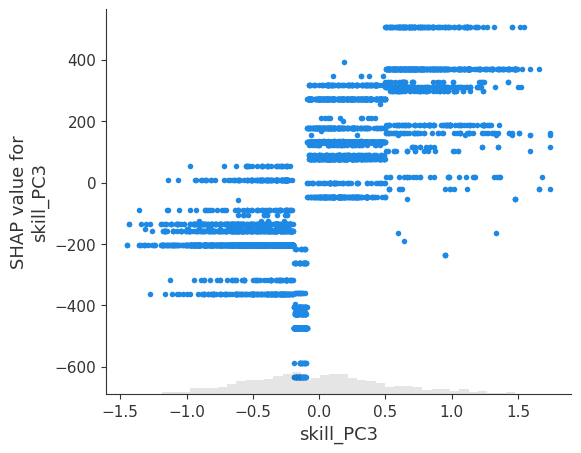

In [23]:
shap.plots.scatter(shap_values[:, "skill_PC3"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC03.png", dpi=300, bbox_inches="tight")

In [24]:
loadings['PC3'].sort_values(ascending=False)

ml_ai__basic                                0.432614
ml_ai__intermediate                         0.415988
analytics_stats__basic                      0.396368
core_programming__basic                     0.285786
domain_specific__none                       0.247982
soft_skills__core                           0.220594
ml_ai__advanced                             0.208863
analytics_stats__intermediate               0.097563
bi_viz__basic                               0.076300
soft_skills__leadership                     0.068574
productivity_workflow__basic                0.043373
cloud__advanced                             0.025745
analytics_stats__advanced                   0.020767
data_engineering_pipelines__advanced        0.018525
productivity_workflow__advanced             0.002369
core_programming__advanced                  0.001158
cloud__intermediate                        -0.002549
bi_viz__advanced                           -0.005586
data_engineering_pipelines__basic          -0.

##### Interpretation — Skill_PC3 (PCA loadings + SHAP dependence)

**What PC3 represents (from PCA loadings):**  
PC3 is dominated by **ML/AI skills** and **analytical depth**, with the strongest positive loadings on **ML/AI (basic, intermediate, advanced)** and **analytics/statistics (especially basic)**, alongside moderate contributions from **core programming (basic)** and **soft skills (core)**. In contrast, PC3 has negative loadings on **data engineering pipelines (intermediate)**, **database/storage (basic and intermediate)**, and to a lesser extent **BI/visualisation (intermediate)**. Conceptually, PC3 separates *model-centric, analytical depth* from *infrastructure- and pipeline-oriented engineering skills*, capturing a **modelling vs engineering orientation** rather than general technical competence.

**How PC3 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **largely monotonic and asymmetric effect**.  
- **Low PC3 values (≈ ≤ −0.5):** SHAP values are consistently **negative**, indicating a salary penalty for roles that emphasise engineering, storage, and pipelines without strong ML or analytical modelling components.  
- **Intermediate PC3 values (≈ −0.3 to 0.3):** SHAP contributions transition rapidly from negative to positive, suggesting a **functional tipping zone** where analytical modelling skills begin to meaningfully influence salary outcomes.  
- **High PC3 values (≈ ≥ 0.4):** SHAP values are strongly and consistently **positive**, with relatively low dispersion, indicating that ML- and modelling-heavy roles receive a clear salary premium.

**Integrated interpretation:**  
PC3 captures a **specialisation premium axis**: roles characterised by strong ML/AI and analytical modelling skills are systematically rewarded with higher predicted salaries, while roles focused on infrastructure and pipeline execution without modelling depth are penalised. Unlike PC1 (baseline gatekeeping) and PC2 (role-orientation trade-off), PC3 exhibits a **clear monotonic payoff**, consistent with labour-market valuation of modelling expertise and algorithmic responsibility. This aligns with the distinction between *data scientist / ML engineer* roles and more infrastructure-focused *data engineer* or operational roles.

**One-sentence summary:**  
*Skill PC3 represents analytical and ML modelling depth, and shows a strong monotonic salary premium: roles with increasing emphasis on ML and statistical modelling are consistently rewarded, while infrastructure-heavy, non-modelling roles are penalised.*


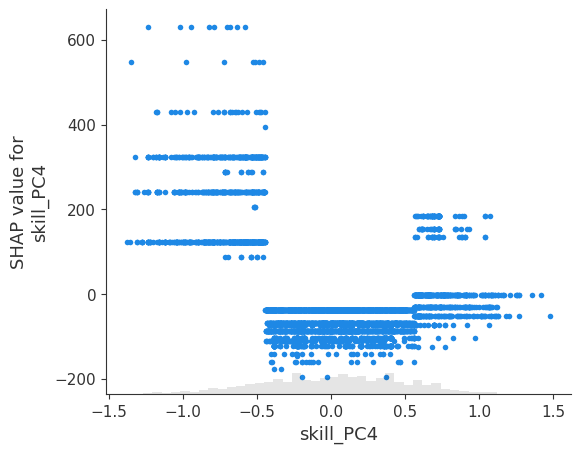

In [25]:
shap.plots.scatter(shap_values[:, "skill_PC4"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC04.png", dpi=300, bbox_inches="tight")

In [26]:
loadings['PC4'].sort_values(ascending=False)

soft_skills__leadership                     0.589484
domain_specific__none                       0.324886
data_engineering_pipelines__intermediate    0.202403
productivity_workflow__intermediate         0.200116
cloud__basic                                0.182416
data_engineering_pipelines__advanced        0.181114
productivity_workflow__basic                0.154850
soft_skills__core                           0.151827
db_storage__intermediate                    0.125436
cloud__intermediate                         0.106026
bi_viz__basic                               0.038248
core_programming__intermediate              0.038017
db_storage__advanced                        0.011874
analytics_stats__basic                      0.010952
data_engineering_pipelines__basic           0.010150
cloud__advanced                             0.009352
core_programming__advanced                  0.000208
productivity_workflow__advanced            -0.001293
ml_ai__advanced                            -0.

##### Interpretation — Skill_PC4 (PCA loadings + SHAP dependence)

**What PC4 represents (from PCA loadings):**  
PC4 is dominated by **leadership and workflow-oriented skills**, with the strongest positive loading on **soft_skills_leadership**, followed by **productivity/workflow (basic–intermediate)**, **domain_specific_none**, and **intermediate-to-advanced data engineering pipelines**. Moderate positive contributions also come from **cloud (basic–intermediate)** and **database/storage (intermediate)**. In contrast, PC4 has strong negative loadings on **core programming (basic)**, **BI/visualisation (intermediate)**, and **database/storage (basic)**. Conceptually, PC4 captures a shift away from hands-on, entry-level technical execution toward **coordination, leadership, and workflow management layered on top of a technical baseline**.

**How PC4 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **bimodal and directionally asymmetric effect**.  
- **Low PC4 values (≈ ≤ −0.6):** SHAP values are strongly **positive**, indicating a salary premium for roles emphasising hands-on technical execution (e.g. core programming, basic BI, basic databases) with limited leadership or workflow responsibility.  
- **Intermediate PC4 values (≈ −0.4 to 0.4):** SHAP values cluster around zero or become mildly negative, suggesting a **neutral-to-penalised zone** where neither strong execution nor clear leadership responsibility dominates.  
- **High PC4 values (≈ ≥ 0.5):** SHAP values become **consistently negative**, indicating a salary penalty for roles that emphasise leadership, coordination, and workflow management without strong signals of deep technical ownership.

**Integrated interpretation:**  
PC4 reflects a **leadership–execution trade-off axis**. The model learns that early-career or strongly hands-on technical roles (low PC4) are rewarded relative to roles that move toward coordination, workflow, and leadership without corresponding increases in seniority, scope, or strategic responsibility. Unlike PC2, which penalises analytics/BI orientation, PC4 penalises *managerial or coordination-heavy skill bundles* that are not paired with high-level authority or advanced technical depth. This suggests that “light leadership” or workflow-heavy roles may be under-valued unless accompanied by explicit seniority signals elsewhere in the model (e.g. title richness).

**One-sentence summary:**  
*Skill PC4 captures a leadership–execution trade-off, where hands-on technical execution is rewarded, while coordination- and workflow-heavy roles without strong seniority or technical depth are associated with lower predicted salaries.*


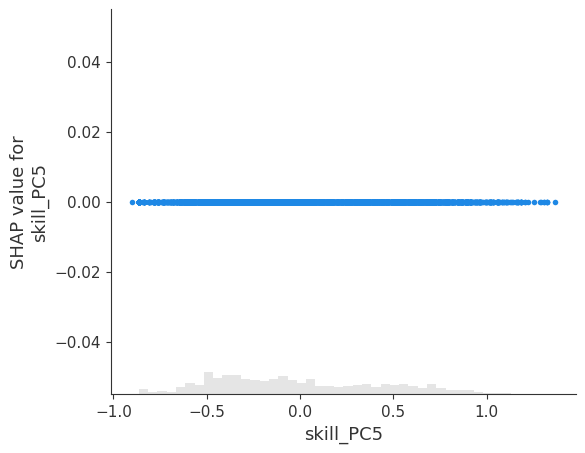

In [27]:
shap.plots.scatter(shap_values[:, "skill_PC5"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC05.png", dpi=300, bbox_inches="tight")

In [28]:
loadings['PC5'].sort_values(ascending=False)

domain_specific__none                       0.836390
bi_viz__intermediate                        0.193085
db_storage__intermediate                    0.171927
cloud__basic                                0.147374
soft_skills__core                           0.096958
core_programming__intermediate              0.030661
db_storage__basic                           0.021055
cloud__advanced                             0.018090
cloud__intermediate                         0.013761
db_storage__advanced                        0.004671
analytics_stats__intermediate               0.003336
bi_viz__advanced                            0.003121
core_programming__advanced                  0.000832
data_engineering_pipelines__basic           0.000656
productivity_workflow__advanced            -0.001472
core_programming__basic                    -0.003284
analytics_stats__advanced                  -0.007591
productivity_workflow__intermediate        -0.017951
ml_ai__advanced                            -0.

##### Interpretation — Skill_PC5 (PCA loadings + SHAP dependence)

**What PC5 represents (from PCA loadings):**  
PC5 is dominated by `domain_specific_none`, with weak and diffuse contributions from BI, database, cloud, and soft-skill features. This component primarily captures residual variance related to the absence of domain-specific requirements rather than a coherent technical or role-oriented skill bundle.

**How PC5 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows SHAP values effectively equal to zero across the entire range of PC5, indicating no meaningful impact on salary predictions.

**Interpretation:**  
PC5 carries negligible explanatory power in the salary model and is effectively ignored once more informative skill dimensions (PC1–PC4) and structural job features are accounted for.

**One-sentence summary:**  
*Skill PC5 captures residual, non-informative variance and has no material effect on predicted salary.*


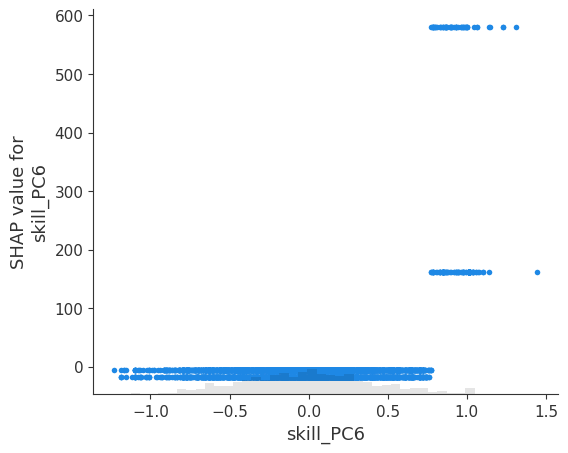

In [29]:
shap.plots.scatter(shap_values[:, "skill_PC6"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC06.png", dpi=300, bbox_inches="tight")

In [30]:
loadings['PC6'].sort_values(ascending=False)

bi_viz__basic                               0.560954
analytics_stats__basic                      0.302165
data_engineering_pipelines__intermediate    0.273704
data_engineering_pipelines__advanced        0.233552
productivity_workflow__basic                0.170187
cloud__intermediate                         0.053244
core_programming__intermediate              0.038589
db_storage__intermediate                    0.030899
domain_specific__none                       0.022008
ml_ai__advanced                             0.017795
cloud__basic                                0.016138
cloud__advanced                             0.015262
data_engineering_pipelines__basic           0.004248
bi_viz__advanced                            0.004038
core_programming__advanced                  0.001625
productivity_workflow__advanced            -0.001680
ml_ai__basic                               -0.002067
db_storage__advanced                       -0.013818
analytics_stats__advanced                  -0.

##### Interpretation — Skill_PC6 (PCA loadings + SHAP dependence)

**What PC6 represents (from PCA loadings):**  
PC6 is driven primarily by **basic BI/visualisation**, **basic analytics/statistics**, and **intermediate-to-advanced data engineering pipelines**, with moderate contributions from **productivity/workflow (basic)**. In contrast, it loads negatively on **soft skills (core and leadership)** and some **basic database and BI intermediate** signals. Conceptually, PC6 captures a *task-focused, execution-heavy analytics profile* that combines hands-on reporting and light engineering, while downweighting leadership and people-oriented responsibilities.

**How PC6 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **highly sparse, step-like effect**. For most of the PC6 range, SHAP values are near zero, indicating little influence on salary. However, for a small subset of observations at **high PC6 values**, SHAP values jump sharply positive, suggesting a **conditional premium** that applies only to specific job profiles exhibiting this skill combination.

**Interpretation:**  
PC6 represents a **niche execution profile** that is usually salary-neutral but can be rewarded in specific contexts—likely roles that combine hands-on analytics/BI with enough engineering responsibility to create measurable business impact, without moving into leadership or modelling-heavy territory.

**One-sentence summary:**  
*Skill PC6 captures a niche analytics–engineering execution profile that is generally salary-neutral but yields a positive premium for a small subset of roles where this combination is particularly valued.*


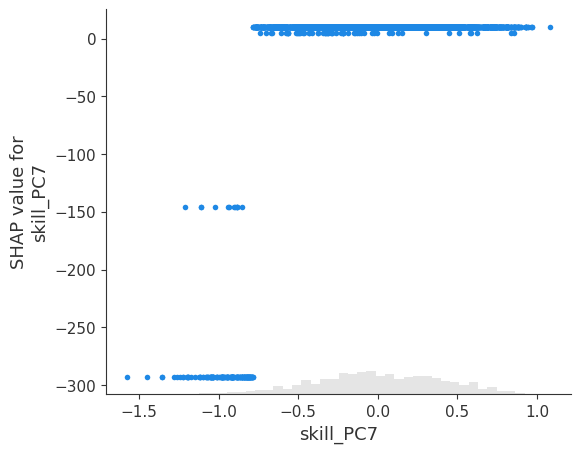

In [31]:
shap.plots.scatter(shap_values[:, "skill_PC7"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC07.png", dpi=300, bbox_inches="tight")

In [32]:
loadings['PC7'].sort_values(ascending=False)

analytics_stats__basic                      0.472641
core_programming__basic                     0.341033
db_storage__basic                           0.149323
domain_specific__none                       0.146990
soft_skills__leadership                     0.078799
core_programming__intermediate              0.050609
data_engineering_pipelines__advanced        0.038472
data_engineering_pipelines__basic           0.008360
db_storage__advanced                        0.004169
core_programming__advanced                  0.000868
productivity_workflow__advanced            -0.001773
analytics_stats__advanced                  -0.002508
bi_viz__advanced                           -0.014552
cloud__advanced                            -0.022253
cloud__intermediate                        -0.024536
productivity_workflow__basic               -0.026903
analytics_stats__intermediate              -0.044919
cloud__basic                               -0.058929
data_engineering_pipelines__intermediate   -0.

##### Interpretation — Skill_PC7 (corrected PCA loadings + SHAP dependence)

**What PC7 represents (from corrected PCA loadings):**  
PC7 contrasts **basic, entry-level analytical/programming skill signals** against **ML-heavy and BI-heavy profiles**. The strongest positive loadings are **analytics & statistics (basic)**, **core programming (basic)**, **basic database/storage**, and **domain_specific_none**, indicating broadly defined, low-specialisation analytical roles. In contrast, strong negative loadings are driven by **ML/AI (basic–intermediate)** and **BI/visualisation (basic–intermediate)**, representing more specialised analytical or tooling-oriented roles.

**How PC7 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **sharp penalty for very low PC7 values**, while the rest of the distribution is largely flat. This indicates that roles strongly aligned with the *negative side* of PC7 (ML/BI-skewed but lacking foundational analytical breadth) are penalised, whereas variation among broadly defined analytical roles has little impact on salary.

**Interpretation:**  
PC7 acts as a **weak discriminator** that primarily flags a subset of roles with *narrow or imbalanced analytical profiles* (e.g. ML/BI without strong basic analytics or general programming), which the model associates with lower pay. Beyond this edge case, PC7 contributes little to salary differentiation.

**One-sentence summary:**  
*Skill PC7 captures a residual contrast between broad, basic analytical roles and narrowly specialised ML/BI profiles, with only the latter incurring a modest salary penalty.*


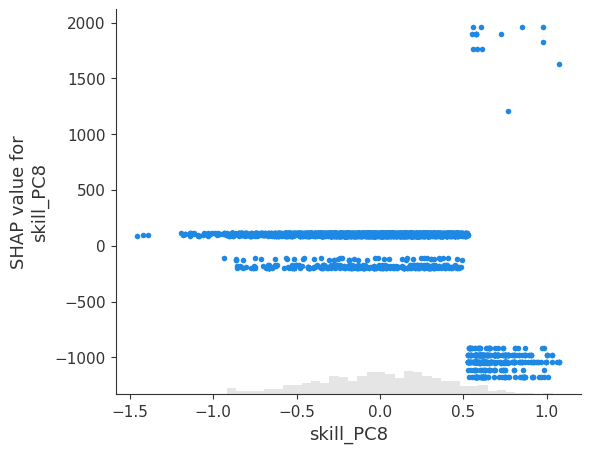

In [33]:
shap.plots.scatter(shap_values[:, "skill_PC8"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC08.png", dpi=300, bbox_inches="tight")

In [34]:
loadings['PC8'].sort_values(ascending=False)

analytics_stats__basic                      0.564250
soft_skills__core                           0.266305
data_engineering_pipelines__intermediate    0.225777
db_storage__intermediate                    0.195479
bi_viz__intermediate                        0.079004
cloud__intermediate                         0.070700
ml_ai__basic                                0.047760
cloud__basic                                0.040116
ml_ai__intermediate                         0.028178
analytics_stats__intermediate               0.012001
db_storage__advanced                        0.008684
data_engineering_pipelines__basic           0.007913
core_programming__advanced                  0.002211
productivity_workflow__advanced            -0.000498
cloud__advanced                            -0.000971
analytics_stats__advanced                  -0.001310
bi_viz__advanced                           -0.002656
core_programming__intermediate             -0.017441
ml_ai__advanced                            -0.

##### Interpretation — Skill_PC8 (PCA loadings + SHAP dependence)

**What PC8 represents (from PCA loadings):**  
PC8 is dominated by **analytics/statistics (basic)** and **soft skills (core)**, with secondary contributions from **intermediate data engineering pipelines**, **intermediate database/storage**, and **intermediate BI/visualisation**. Negative loadings are associated with **core programming (basic)**, **productivity workflow (basic)**, **advanced pipelines**, and **leadership-oriented soft skills**. Conceptually, PC8 contrasts *foundational analytical + communication-oriented roles* against *more engineering- or production-heavy technical profiles*.

**How PC8 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot shows a **strongly non-linear and asymmetric pattern**:
- **High PC8 values:** For a subset of postings, PC8 contributes **very large positive SHAP values**, indicating a sharp salary uplift when analytical/statistical foundations and core soft skills co-occur in specific contexts (likely analytically intensive roles embedded in higher-paying environments).
- **Moderate to low PC8 values:** Most observations cluster around **moderate negative SHAP contributions**, suggesting that emphasizing these skills alone—without complementary advanced technical or role-defining signals—tends to correlate with lower predicted salaries.
- **Dispersion and sparsity:** The extreme positive effects are sparse, implying **context dependence** rather than a general monotonic relationship.

**Substantive takeaway:**  
PC8 captures an *analytics–communication foundation axis* that is **not universally rewarded**. In most cases, it is weakly or negatively associated with salary, but in specific job configurations it becomes **highly valuable**, producing outsized salary gains. This suggests PC8 acts as a **conditional amplifier** rather than a baseline or gatekeeper skill dimension.

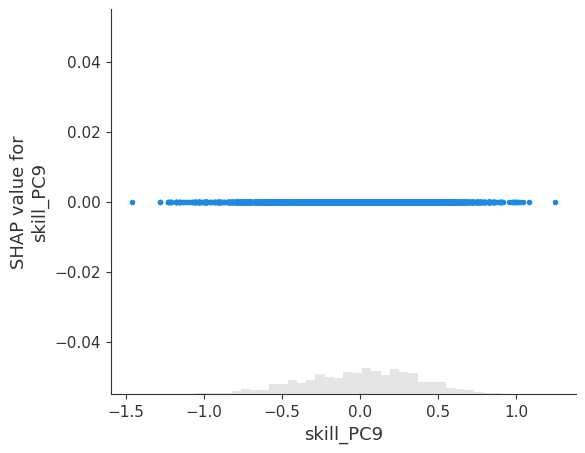

In [35]:
shap.plots.scatter(shap_values[:, "skill_PC9"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC09.png", dpi=300, bbox_inches="tight")

In [36]:
loadings['PC9'].sort_values(ascending=False)

soft_skills__core                           0.609482
cloud__basic                                0.293120
core_programming__basic                     0.247358
productivity_workflow__intermediate         0.207940
bi_viz__basic                               0.167746
cloud__intermediate                         0.139401
productivity_workflow__basic                0.112134
db_storage__intermediate                    0.097725
core_programming__intermediate              0.075627
data_engineering_pipelines__advanced        0.042394
cloud__advanced                             0.031239
data_engineering_pipelines__basic           0.015081
db_storage__advanced                        0.012751
bi_viz__advanced                            0.004734
core_programming__advanced                  0.003578
productivity_workflow__advanced            -0.001084
analytics_stats__advanced                  -0.021888
analytics_stats__basic                     -0.028823
ml_ai__advanced                            -0.

##### Interpretation — Skill_PC9 (PCA loadings + SHAP dependence)

**What PC9 represents (from PCA loadings):**  
PC9 reflects **entry-level generalist skills**, dominated by *soft skills (core)*, *basic cloud*, *basic programming*, *basic BI*, and *basic productivity workflows*. Negative loadings are associated with *ML/AI*, *domain-specific absence*, and *advanced technical depth*.

**How PC9 affects salary predictions (from SHAP dependence):**  
The SHAP dependence is essentially **flat around zero across the full range**, indicating no meaningful contribution to salary predictions.

**Substantive takeaway:**  
PC9 captures **low-signal, ubiquitous skills** that are common across roles and therefore do not differentiate pay; the model correctly treats this dimension as largely irrelevant for salary determination.

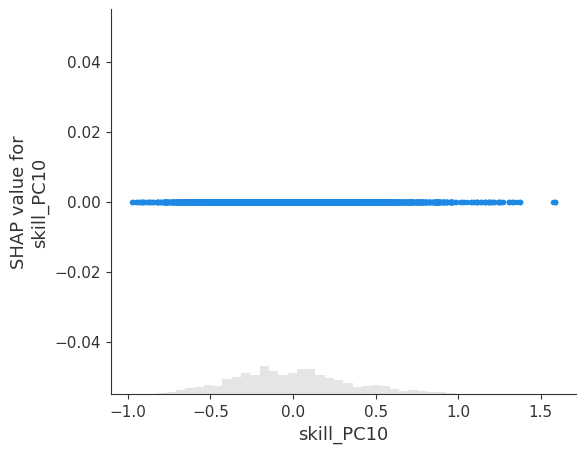

In [37]:
shap.plots.scatter(shap_values[:, "skill_PC10"], show=False)
plt.savefig(OUT_DIR / "shap_dep_skill_PC10.png", dpi=300, bbox_inches="tight")

In [38]:
loadings['PC10'].sort_values(ascending=False)

productivity_workflow__intermediate         0.495855
productivity_workflow__basic                0.465802
db_storage__basic                           0.290459
analytics_stats__basic                      0.185006
db_storage__intermediate                    0.150755
data_engineering_pipelines__advanced        0.099825
ml_ai__advanced                             0.071349
ml_ai__basic                                0.059303
ml_ai__intermediate                         0.041405
domain_specific__none                       0.034769
cloud__advanced                             0.005527
bi_viz__advanced                            0.004454
productivity_workflow__advanced             0.001789
data_engineering_pipelines__basic          -0.000478
core_programming__advanced                 -0.001169
analytics_stats__advanced                  -0.010742
db_storage__advanced                       -0.018985
cloud__intermediate                        -0.019387
analytics_stats__intermediate              -0.

##### Interpretation — Skill_PC10 (PCA loadings + SHAP dependence)

**What PC10 represents (from PCA loadings):**  
PC10 is dominated by **productivity/workflow (basic–intermediate)** and **database/storage (basic–intermediate)**, with smaller contributions from **analytics (basic)** and **data engineering (advanced)**. This component captures a *light operational hygiene* axis—process, workflow organisation, and entry-level data handling—rather than deep technical specialisation.

**How PC10 affects salary predictions (from SHAP dependence):**  
The SHAP dependence plot is effectively **flat at zero across the entire range** of PC10 values. There is no visible threshold, slope, or segmentation, indicating **no marginal effect on salary** once other components are accounted for.

**Substantive takeaway:**  
PC10 encodes *background operational traits* that are common across many roles and **do not differentiate pay**. These skills are expected or ubiquitous and therefore absorbed by higher-order components (e.g., PC1–PC3), leaving PC10 with **negligible standalone explanatory power** for salary.

### We now move to the categorical variables

#### Lookup tables for actual labels

In [39]:
size_lookup = (
    df_ch0[["size_code", "Size"]]
    .drop_duplicates(subset="size_code")
    .sort_values("size_code")
)

sector_lookup = (
    df_ch0[["sector_code", "Sector"]]
    .drop_duplicates(subset="sector_code")
    .sort_values("sector_code")
)

state_lookup = (
    df_ch0[["state_code", "state"]]
    .drop_duplicates(subset="state_code")
    .sort_values("state_code")
)

ownership_lookup = (
    df_ch0[["ownership_code", "ownership_clean"]]
    .drop_duplicates(subset="ownership_code")
    .sort_values("ownership_code")
)

seniority_lookup = (
    df_ch0[["seniority_code", "seniority_combined"]]
    .drop_duplicates(subset="seniority_code")
    .sort_values("seniority_code")
)

title_lookup = (
    df_ch0[["title_rich_code", "title_rich"]]
    .drop_duplicates(subset="title_rich_code")
    .sort_values("title_rich_code")
)

In [40]:
shap_values.feature_names

['size_code',
 'sector_code',
 'state_code',
 'ownership_code',
 'seniority_code',
 'title_rich_code',
 'skill_PC1',
 'skill_PC2',
 'skill_PC3',
 'skill_PC4',
 'skill_PC5',
 'skill_PC6',
 'skill_PC7',
 'skill_PC8',
 'skill_PC9',
 'skill_PC10']

#### Combine shap for categorical features in one table

In [41]:
feat_idx = {name: i for i, name in enumerate(shap_values.feature_names)}

size_shap_df = pd.DataFrame({
    "size_code": shap_values.data[:, feat_idx["size_code"]],
    "size_shap": shap_values.values[:, feat_idx["size_code"]],
}).merge(size_lookup, on="size_code", how="left")

sector_shap_df = pd.DataFrame({
    "sector_code": shap_values.data[:, feat_idx["sector_code"]],
    "sector_shap": shap_values.values[:, feat_idx["sector_code"]],
}).merge(sector_lookup, on="sector_code", how="left")

state_shap_df = pd.DataFrame({
    "state_code": shap_values.data[:, feat_idx["state_code"]],
    "state_shap": shap_values.values[:, feat_idx["state_code"]],
}).merge(state_lookup, on="state_code", how="left")

ownership_shap_df = pd.DataFrame({
    "ownership_code": shap_values.data[:, feat_idx["ownership_code"]],
    "ownership_shap": shap_values.values[:, feat_idx["ownership_code"]],
}).merge(ownership_lookup, on="ownership_code", how="left")

seniority_shap_df = pd.DataFrame({
    "seniority_code": shap_values.data[:, feat_idx["seniority_code"]],
    "seniority_shap": shap_values.values[:, feat_idx["seniority_code"]],
}).merge(seniority_lookup, on="seniority_code", how="left")

title_shap_df = pd.DataFrame({
    "title_rich_code": shap_values.data[:, feat_idx["title_rich_code"]],
    "title_shap": shap_values.values[:, feat_idx["title_rich_code"]],
}).merge(title_lookup, on="title_rich_code", how="left")


In [42]:
for df_, label_col in [
    (size_shap_df, "Size"),
    (sector_shap_df, "Sector"),
    (state_shap_df, "state"),
    (ownership_shap_df, "ownership_clean"),
    (seniority_shap_df, "seniority_combined"),
    (title_shap_df, "title_rich"),
]:
    print(label_col, df_[label_col].isna().sum())


Size 0
Sector 0
state 0
ownership_clean 0
seniority_combined 0
title_rich 0


#### Seniority

In [43]:
seniority_summary = (
    seniority_shap_df
    .groupby("seniority_combined", as_index=False)
    .agg(
        mean_shap=("seniority_shap", "mean"),
        median_shap=("seniority_shap", "median"),
        n=("seniority_shap", "size")
    )
    .sort_values("mean_shap", ascending=False)
)
seniority_summary

,seniority_combined,mean_shap,median_shap,n
0,assistant,0.0,0.0,11
1,executive,0.0,0.0,97
2,junior,0.0,0.0,256
3,lead,0.0,0.0,254
4,manager,0.0,0.0,294
5,mid,0.0,0.0,193
6,principal,0.0,0.0,221
7,senior,0.0,0.0,880
8,supervisor,0.0,0.0,4
9,unknown,0.0,0.0,2718


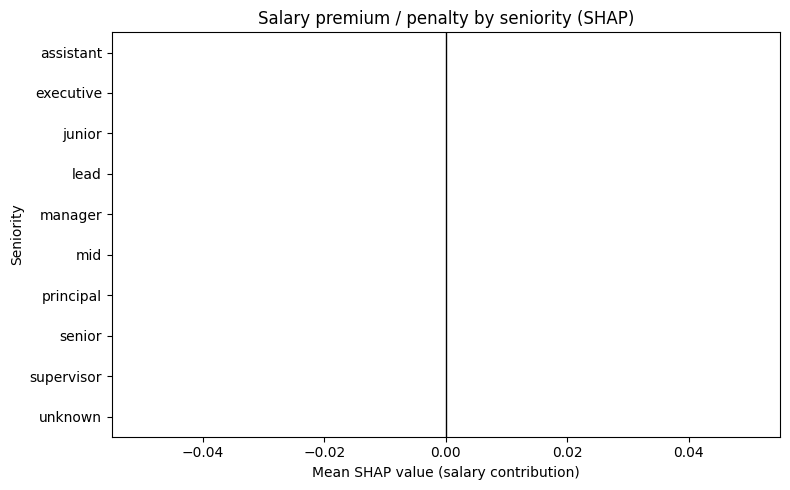

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=seniority_summary,
    x="mean_shap",
    y="seniority_combined",
    orient="h"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Salary premium / penalty by seniority (SHAP)")
plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("Seniority")
plt.tight_layout()

plt.savefig(OUT_DIR / "shap_penalty_seniority.png", dpi=300, bbox_inches="tight")

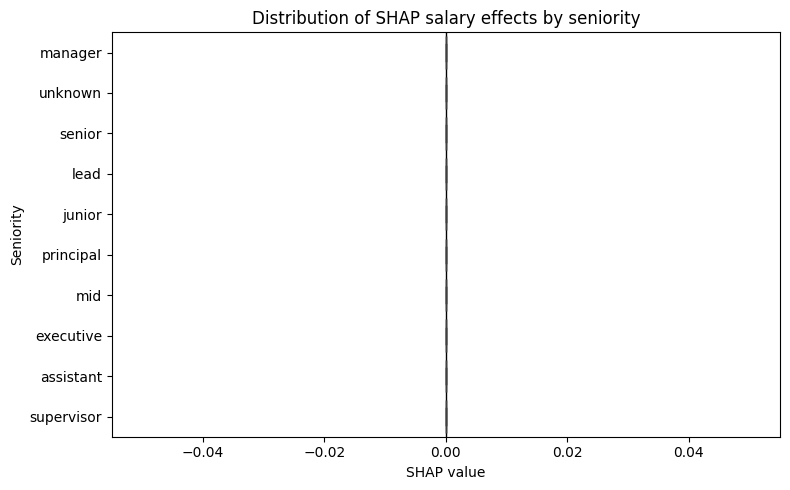

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=seniority_shap_df,
    x="seniority_shap",
    y="seniority_combined",
    showfliers=False
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Distribution of SHAP salary effects by seniority")
plt.xlabel("SHAP value")
plt.ylabel("Seniority")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_seniority.png", dpi=300, bbox_inches="tight")

**Interpretation (Seniority – SHAP):**  
Seniority exhibits near-zero SHAP contributions across all levels, indicating no independent effect on salary predictions once skills, title richness, sector, location, and company characteristics are controlled for. This suggests that the salary signal commonly associated with seniority is fully mediated by role content and skill composition rather than the seniority label itself.


#### Size

In [46]:
# Summary table
size_summary = (
    size_shap_df
    .groupby("Size", as_index=False)
    .agg(
        mean_shap=("size_shap", "mean"),
        median_shap=("size_shap", "median"),
        n=("size_shap", "size")
    )
    .sort_values("mean_shap", ascending=False)
)
size_summary

,Size,mean_shap,median_shap,n
1,10000+ employees,576.593079,559.179871,1100
2,1001 to 5000 employees,535.795105,495.529816,721
6,51 to 200 employees,379.902740,364.882751,798
7,Unknown,-251.456970,-271.945618,398
4,5001 to 10000 employees,-535.424072,-530.284668,252
3,201 to 500 employees,-539.576294,-505.474060,529
5,501 to 1000 employees,-700.063721,-710.320923,412
0,1 to 50 employees,-708.739136,-689.588867,718


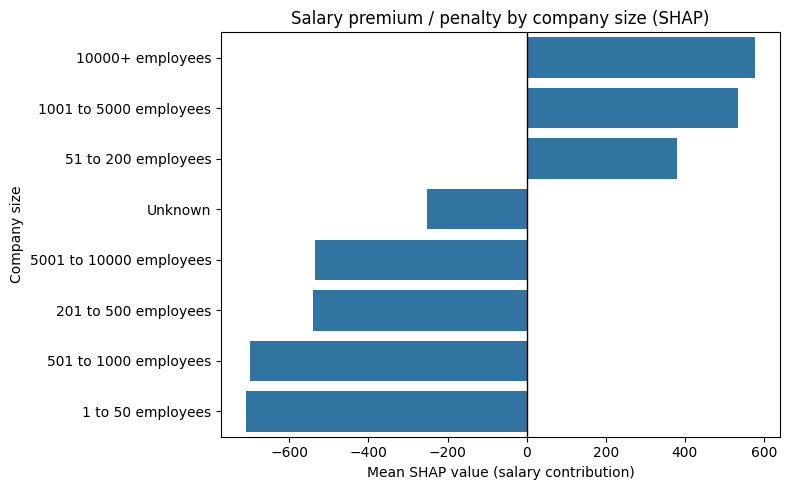

In [47]:
# Bar plot: mean SHAP by company size
plt.figure(figsize=(8, 5))
sns.barplot(
    data=size_summary,
    x="mean_shap",
    y="Size",
    orient="h"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Salary premium / penalty by company size (SHAP)")
plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("Company size")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_penalty_size.png", dpi=300, bbox_inches="tight")

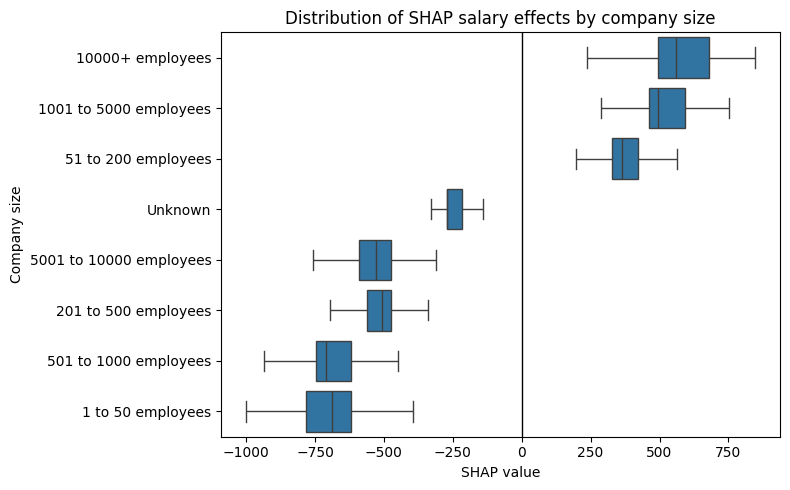

In [48]:
# Optional: distribution (heterogeneity)
plt.figure(figsize=(8, 5))

order = size_summary["Size"].dropna().drop_duplicates().tolist()
sns.boxplot(
    data=size_shap_df,
    x="size_shap",
    y="Size",
    order = order,
    showfliers=False
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Distribution of SHAP salary effects by company size")
plt.xlabel("SHAP value")
plt.ylabel("Company size")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_size.png", dpi=300, bbox_inches="tight")

##### Interpretation — Company Size (categorical SHAP effects)

**What the variable captures:**  
Company size encodes organisational scale, complexity, and resource availability, which are strongly linked to pay-setting power, role scope, and career ladders.

**Observed salary premiums / penalties (from SHAP):**
- **Large enterprises (10000+ employees, 1001–5000 employees):**  
  These categories show the **largest positive SHAP contributions**, indicating a consistent salary premium. This reflects higher budgets, formalised compensation bands, and roles with broader organisational impact.
- **Mid-sized firms (51–200 employees):**  
  Still show a **positive premium**, but notably smaller than large enterprises, suggesting partial access to scale benefits without full enterprise compensation structures.
- **Small firms (1–50, 201–500, 501–1000 employees):**  
  Exhibit **strong negative SHAP values**, indicating a clear salary penalty. These roles likely involve narrower scope, fewer progression pathways, and tighter budget constraints.
- **Very large mid-range (5001–10000 employees):**  
  Surprisingly negative on average, suggesting heterogeneity: this band may mix scale without the compensation advantages of top-tier enterprises.
- **Unknown size:**  
  Moderately negative, likely reflecting informational uncertainty or lower-quality postings that the model associates with reduced pay.

**Distributional insight:**  
Boxplots show **tight within-category distributions**, meaning size effects are systematic rather than driven by outliers.

**Substantive takeaway:**  
Company size acts as a **structural salary determinant** rather than a skill-related one. Unlike PCs (which show thresholds and diminishing returns), size introduces **stepwise salary regimes**, with clear penalties for small firms and strong premiums at true enterprise scale.


#### Sector

In [49]:
# --- Aggregate SHAP effects by sector ---
sector_summary = (
    sector_shap_df
    .groupby("Sector", as_index=False)
    .agg(
        mean_shap=("sector_shap", "mean"),
        median_shap=("sector_shap", "median"),
        n=("sector_shap", "size")
    )
    .sort_values("mean_shap", ascending=False)
)

sector_summary


,Sector,mean_shap,median_shap,n
6,"Construction, Repair & Maintenance",3275.311279,2906.895020,24
12,Information Technology,2883.979004,2460.922363,1357
0,Accounting & Legal,2640.005615,2455.952637,95
14,Manufacturing,2533.335693,2522.038086,102
4,Biotech & Pharmaceuticals,1475.115112,1324.359375,255
3,"Arts, Entertainment & Recreation",1176.903198,839.120483,16
19,Real Estate,1013.048950,1110.086304,17
22,Telecommunications,851.712463,1074.825073,26
7,Consumer Services,-307.531006,-203.612732,27
18,"Oil, Gas, Energy & Utilities",-412.753296,-790.109802,39


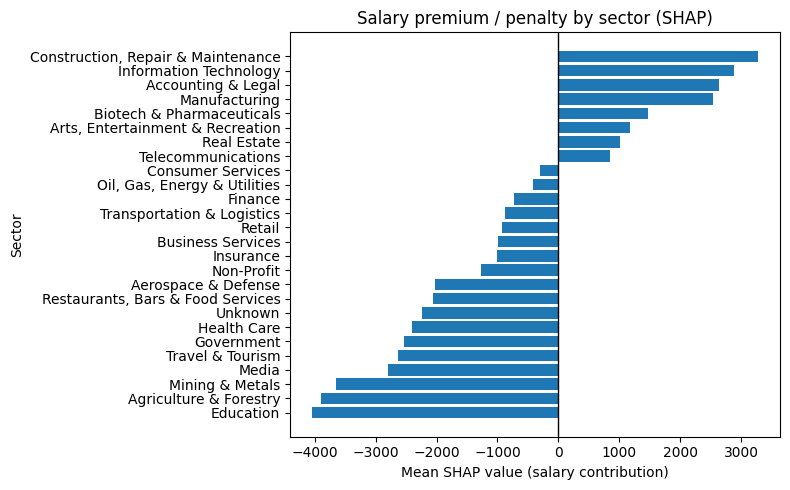

In [50]:
# --- Bar plot: mean salary premium / penalty by sector ---
plt.figure(figsize=(8, 5))

plt.barh(
    sector_summary["Sector"],
    sector_summary["mean_shap"]
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("Sector")
plt.title("Salary premium / penalty by sector (SHAP)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_penalty_sector.png", dpi=300, bbox_inches="tight")

/var/folders/vx/4t7xz04d6_39xszmh_6hq4br0000gn/T/ipykernel_76746/50004201.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


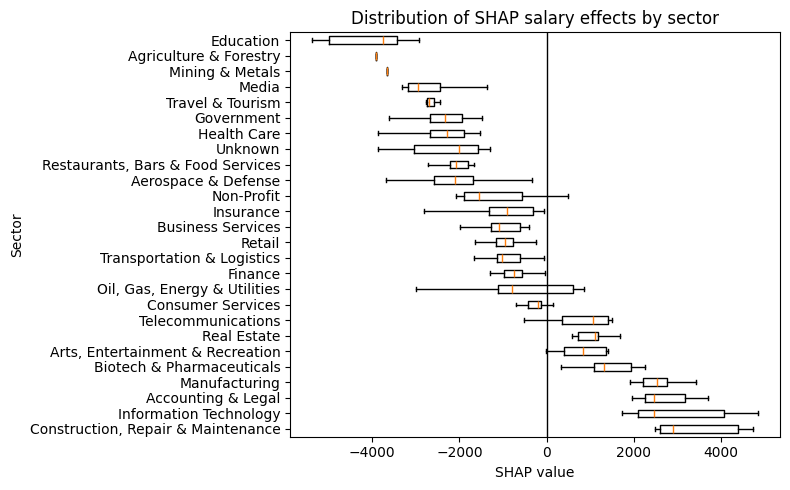

In [51]:
# --- Distribution plot: SHAP effects by sector ---
plt.figure(figsize=(8, 5))

sector_order = sector_summary["Sector"].dropna().drop_duplicates().tolist()

data = [
    sector_shap_df.loc[sector_shap_df["Sector"] == s, "sector_shap"]
    for s in sector_order
]

plt.boxplot(
    data,
    labels=sector_order,
    vert=False,
    showfliers=False
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP value")
plt.ylabel("Sector")
plt.title("Distribution of SHAP salary effects by sector")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_sector.png", dpi=300, bbox_inches="tight")

##### Interpretation — Sector (SHAP salary effects)

Sector exhibits the **largest absolute salary effects** among all categorical variables, indicating that industry context is one of the strongest structural drivers of pay in the model.

**High-premium sectors** include:
- **Construction, Repair & Maintenance**, **Information Technology**, **Accounting & Legal**, and **Manufacturing**, all showing strong positive SHAP contributions. These sectors are typically associated with higher capital intensity, revenue per employee, or strong demand for technical expertise.
- **Biotech & Pharmaceuticals** and **Telecommunications** also provide consistent salary premiums, reflecting specialised knowledge and regulatory complexity.

**Neutral to mildly negative sectors** (e.g. Consumer Services, Finance, Transportation & Logistics) cluster near zero, suggesting moderate pay once other factors (skills, title, location) are accounted for.

**Strong salary penalties** are observed for:
- **Education**, **Agriculture & Forestry**, **Mining & Metals**, **Media**, **Government**, and **Health Care**.
These penalties likely reflect institutional wage constraints, public funding structures, or lower market competition for data roles rather than individual skill deficits.

**Key takeaway:**  
Sector acts as a **macro-economic prior** on salary: it shifts the baseline pay expectation substantially before skills or seniority are considered. This reinforces that salary differences are not purely merit- or skill-based, but strongly conditioned by industry context.

#### State

In [52]:
state_summary = (
    state_shap_df
    .groupby("state", dropna=False)
    .agg(
        mean_shap=("state_shap", "mean"),
        median_shap=("state_shap", "median"),
        n=("state_shap", "size")
    )
    .reset_index()
    .sort_values("mean_shap", ascending=False)
)
state_summary

,state,mean_shap,median_shap,n
1,CA,19586.193359,19235.630859,1363
11,NY,5630.903320,3114.091064,514
19,international,96.728027,-1775.951843,4
3,DE,-11.592214,-2076.916016,17
0,AZ,-3769.227539,-3969.613647,300
10,NJ,-4760.025879,-5293.625000,95
15,TX,-8466.158203,-8160.145508,1313
13,PA,-10400.569336,-9818.265625,344
2,CO,-10427.279297,-10067.871094,80
6,IL,-11245.211914,-10115.748047,432


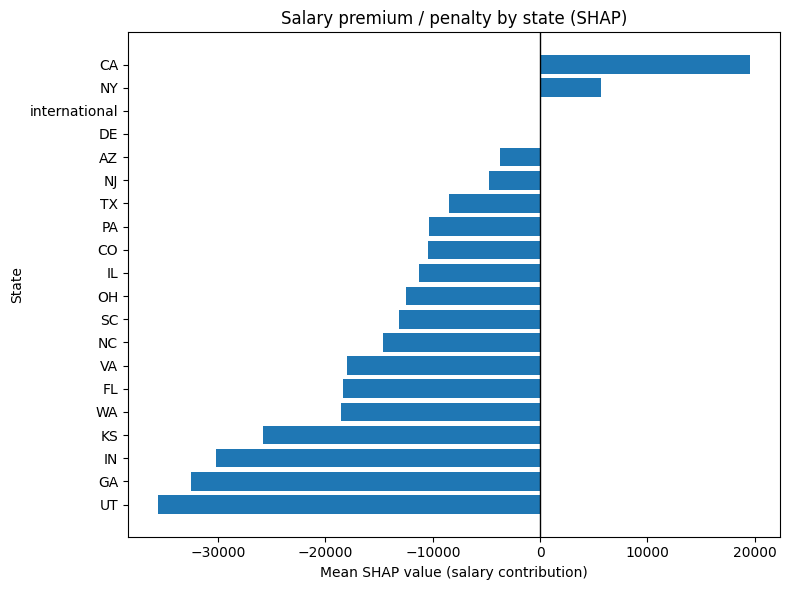

In [53]:
plt.figure(figsize=(8, 6))

plt.barh(
    state_summary["state"],
    state_summary["mean_shap"]
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("State")
plt.title("Salary premium / penalty by state (SHAP)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_penalty_state.png", dpi=300, bbox_inches="tight")

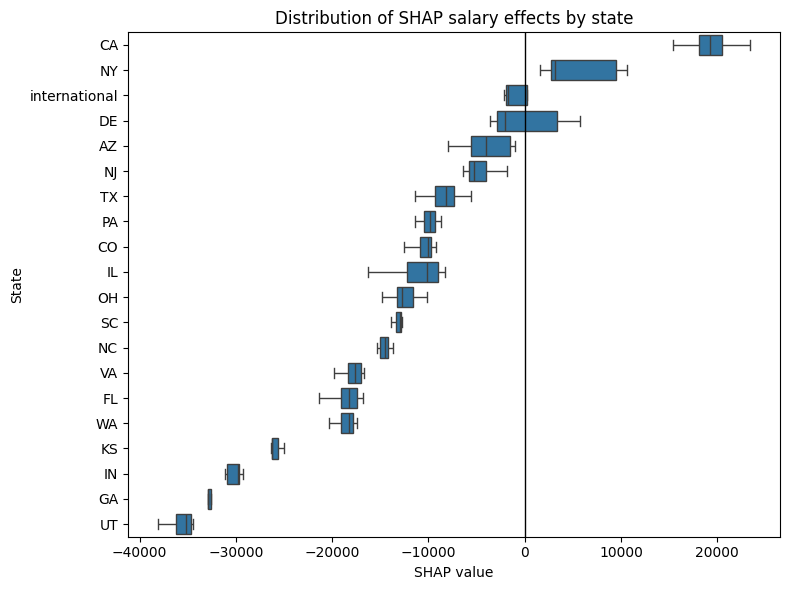

In [54]:
plt.figure(figsize=(8, 6))

order = state_summary["state"].dropna().drop_duplicates().tolist()

sns.boxplot(
    data=state_shap_df,
    x="state_shap",
    y="state",
    order=order,
    showfliers=False
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("SHAP value")
plt.ylabel("State")
plt.title("Distribution of SHAP salary effects by state")

plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_state.png", dpi=300, bbox_inches="tight")

##### Interpretation — State (SHAP salary effects)

Geographic location exhibits the **largest absolute salary effects in the model**, exceeding those of skills, sector, and ownership. This confirms that **location is a dominant structural determinant of pay**, not merely a contextual modifier.

**Key patterns**
- **California (CA)** shows an extremely large positive SHAP contribution, indicating a substantial salary premium even after controlling for skills, company size, sector, and role characteristics.
- **New York (NY)** also shows a strong positive premium, though notably smaller than CA, suggesting a clear hierarchy among high-cost, high-demand labour markets.
- Most other states show **negative SHAP values**, indicating systematic salary penalties relative to the model baseline.
- Several states (e.g. UT, GA, IN, KS) show very large negative effects, reflecting regional wage structures rather than lower skill requirements.

**Distributional insight**
- Within-state SHAP distributions are relatively tight compared to the cross-state differences, indicating that **state effects are consistent across roles** rather than driven by a few outliers.
- Small-sample states (low `n`) should be interpreted cautiously, but the overall gradient is robust for high-frequency states.

**Interpretation**
State captures:
- Cost of living
- Local labour market competition
- Regional industry concentration
- Pay norms and regulatory environments

Importantly, this is **not a skill effect**. The model indicates that identical jobs with identical skill profiles are paid very differently depending on location.

This validates the inclusion of geography as a **first-order salary driver** in the system.

#### Ownership

In [55]:
ownership_summary = (
    ownership_shap_df
    .groupby("ownership_clean")
    .agg(
        mean_shap=("ownership_shap", "mean"),
        median_shap=("ownership_shap", "median"),
        n=("ownership_shap", "size")
    )
    .reset_index()
    .sort_values("mean_shap", ascending=False)
)

ownership_summary

,ownership_clean,mean_shap,median_shap,n
3,public,128.226364,93.371277,1459
2,private,124.915344,93.371277,2578
4,unknown,118.738365,86.222755,380
0,government,109.770988,93.371277,101
1,nonprofit,-1327.500488,-1028.409424,410


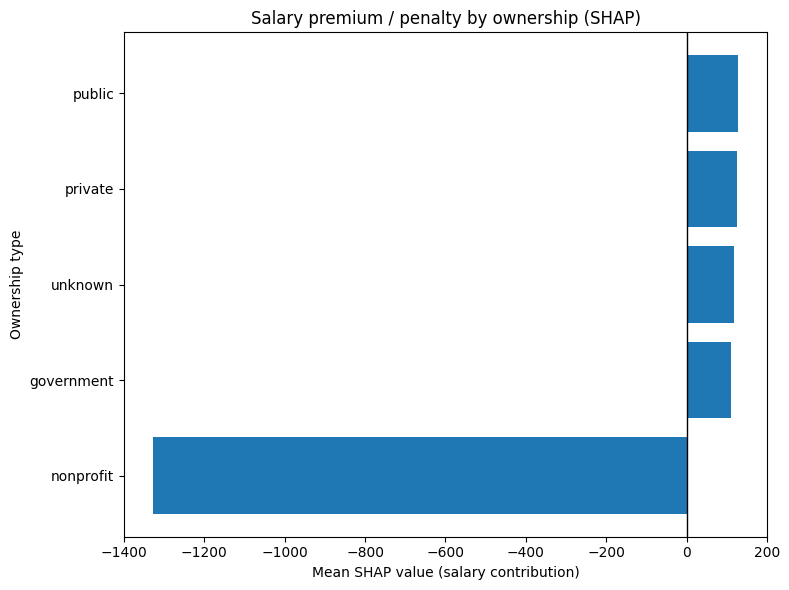

In [56]:
# ---------------------------------------------
# Ownership: mean SHAP bar plot
# ---------------------------------------------
plt.figure(figsize=(8, 6))
plt.barh(
    ownership_summary["ownership_clean"],
    ownership_summary["mean_shap"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("Ownership type")
plt.title("Salary premium / penalty by ownership (SHAP)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_penalty_ownership.png", dpi=300, bbox_inches="tight")

/var/folders/vx/4t7xz04d6_39xszmh_6hq4br0000gn/T/ipykernel_76746/2969547889.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


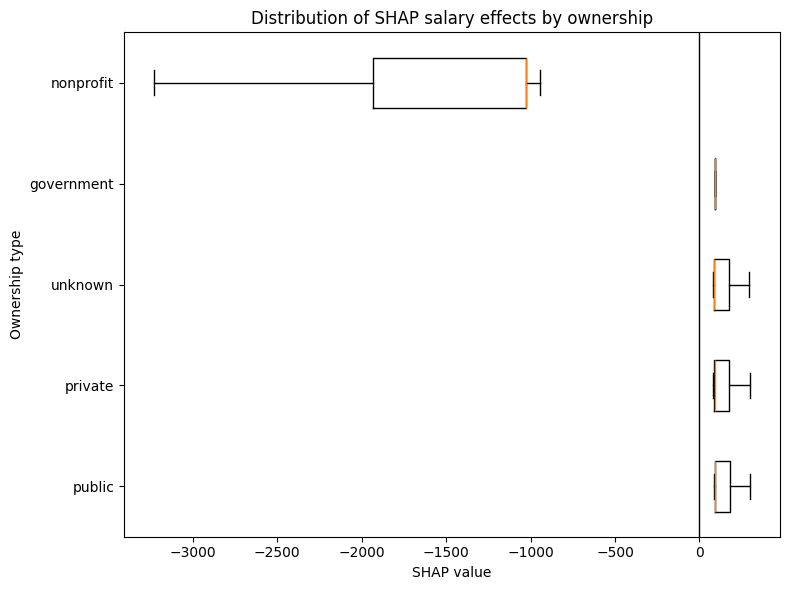

In [57]:
ownership_order = ownership_summary["ownership_clean"].dropna().drop_duplicates().tolist()

data = [
    ownership_shap_df.loc[
        ownership_shap_df["ownership_clean"] == o,
        "ownership_shap"
    ]
    for o in ownership_order
]

plt.figure(figsize=(8, 6))
plt.boxplot(
    data,
    labels=ownership_order,
    vert=False,
    showfliers=False
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP value")
plt.ylabel("Ownership type")
plt.title("Distribution of SHAP salary effects by ownership")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_ownership.png", dpi=300, bbox_inches="tight")

##### Interpretation — Ownership (SHAP salary effects)

Ownership type has a relatively modest effect on salary compared to location or sector, but clear patterns still emerge.

Public, private, and government organizations all show small positive SHAP contributions, suggesting broadly comparable compensation levels once other factors are controlled for.

In contrast, nonprofit organizations exhibit a large and consistent negative SHAP value, indicating a substantial salary penalty associated with nonprofit employment. This penalty is stable across observations, as shown by the narrow SHAP distribution.

The sharp contrast between nonprofit and other ownership types suggests that ownership captures **institutional pay constraints** rather than skill composition or job mix.

Overall, ownership contributes secondary but interpretable structure to the salary model, with nonprofit status acting as a strong downward adjustment.


#### Title

In [58]:
title_summary = (
    title_shap_df
    .groupby("title_rich")
    .agg(
        mean_shap=("title_shap", "mean"),
        median_shap=("title_shap", "median"),
        n=("title_shap", "size")
    )
    .sort_values("mean_shap", ascending=False)
    .reset_index()
)

title_summary

,title_rich,mean_shap,median_shap,n
0,ML_AI_scientist,22950.216797,23441.949219,24
1,ML_AI_data_scientist,21863.517578,23159.513672,48
2,business_data_scientist,19883.636719,20589.894531,81
3,general_data_data_scientist,18514.156250,19781.110352,824
4,ML_AI_data_engineer,17607.958984,18472.568359,96
5,general_data_scientist,17084.679688,17084.679688,2
6,sport_data_scientist,15422.343750,15422.343750,2
7,ML_AI_data_analyst,13784.520508,15415.610352,4
8,research_data_scientist,11789.156250,9433.676758,12
9,health_data_engineer,11203.107422,11203.107666,2


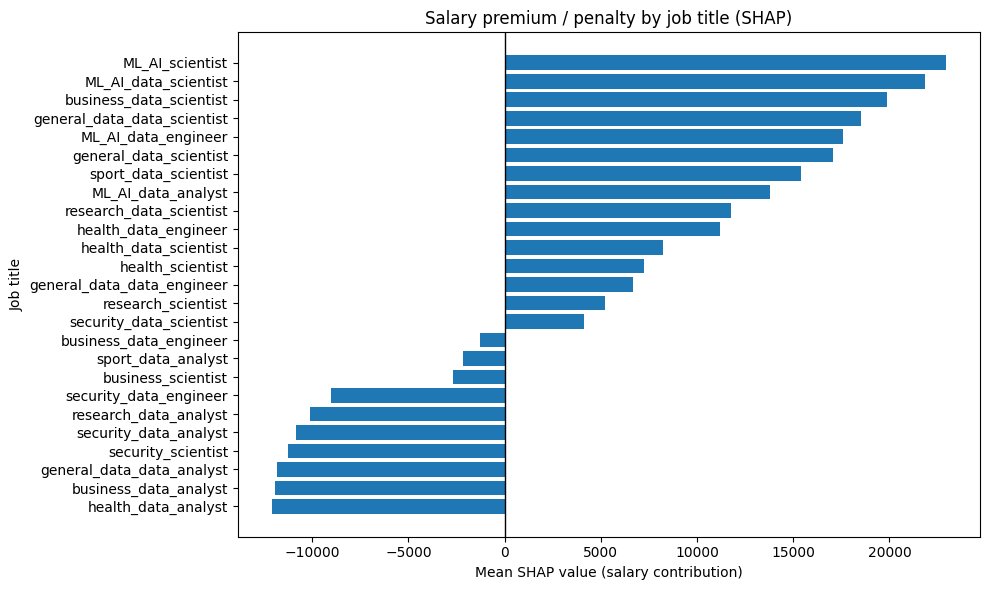

In [59]:
plt.figure(figsize=(10, 6))
plt.barh(
    title_summary["title_rich"],
    title_summary["mean_shap"]
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean SHAP value (salary contribution)")
plt.ylabel("Job title")
plt.title("Salary premium / penalty by job title (SHAP)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_penalty_title.png", dpi=300, bbox_inches="tight")

/var/folders/vx/4t7xz04d6_39xszmh_6hq4br0000gn/T/ipykernel_76746/3770746322.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=order)


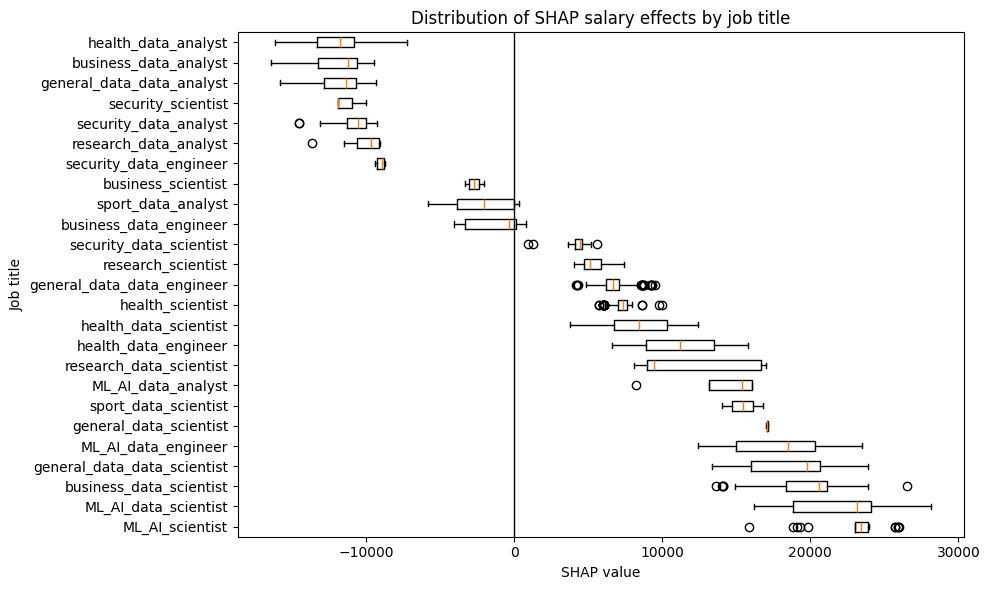

In [60]:
plt.figure(figsize=(10, 6))

order = title_summary["title_rich"].dropna().drop_duplicates().tolist()

data = [
    title_shap_df.loc[title_shap_df["title_rich"] == t, "title_shap"]
    for t in order
]

plt.boxplot(data, vert=False, labels=order)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("SHAP value")
plt.ylabel("Job title")
plt.title("Distribution of SHAP salary effects by job title")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_distribution_title.png", dpi=300, bbox_inches="tight")

##### Interpretation — Job Title (SHAP salary effects)

**Overall pattern:**  
Job title is the **single most discriminative categorical variable** in the model, producing the largest and cleanest separation between salary premiums and penalties.

**High-premium titles:**
- Titles explicitly combining **ML/AI with Data Scientist or Engineer** (e.g. `ML_AI_scientist`, `ML_AI_data_scientist`, `ML_AI_data_engineer`) show the **largest positive SHAP values**, often exceeding +20k.
- Specialized or domain-enhanced data scientist roles (e.g. business, research, health) retain strong positive contributions but at lower magnitudes.

**Low-premium / penalty titles:**
- **Data analyst roles** (general, business, health) consistently show large **negative SHAP values**, often comparable in magnitude (but opposite in sign) to ML/AI scientist premiums.
- Security- and research-focused analyst roles sit among the strongest penalties, reflecting narrower scope or non-market-aligned pay structures.

**Distributional insight:**
- Boxplots show **tight, well-separated distributions**, indicating that title effects are not driven by noise or outliers.
- Overlap between adjacent roles (e.g. research scientist vs general data scientist) reflects genuine labor-market ambiguity rather than model uncertainty.

**Interpretation:**  
The model has learned a **clear occupational hierarchy**:  
> *ML/AI scientist → data scientist → data engineer → analyst*  

Titles act as a **compressed signal of responsibility, specialization, and market value**, effectively summarizing multiple latent factors (seniority, skill depth, business impact) that are only partially captured elsewhere in the feature set.

### Global SHAP interpretation

The global SHAP analysis shows that job title, location (state), sector, and company size dominate salary predictions, with skill composition acting primarily as a secondary, moderating layer rather than the main driver. The first two skill principal components (PC1 and PC2) capture broad structural differences in job type and technical depth, while later PCs contribute little marginal explanatory power. Importantly, the model exhibits threshold and plateau behaviour rather than smooth linear effects: certain features act as gatekeepers (e.g., foundational technical skills or title class), beyond which additional signal yields diminishing returns. Several PCs and categorical variables show near-zero SHAP impact, indicating that the model has learned they add little incremental information once higher-level structure is accounted for. Overall, the global SHAP profile confirms that salary is primarily a market-structural outcome, with skills shaping trajectories within those structures rather than defining them outright.

### Local SHAP interpretation

**Skill_PC1**

PC1 represents foundational technical infrastructure skills (pipelines, databases, core programming, cloud). Its SHAP dependence shows a strong threshold effect, where low PC1 values incur a large salary penalty, but gains flatten once a baseline is reached. This indicates PC1 functions as a minimum technical requirement rather than a differentiator at higher salary levels.

**Skill_PC2**

PC2 loads heavily on analytical, BI, and softer quantitative skills. Higher PC2 values are associated with negative salary contributions, consistent with roles skewing toward data analyst profiles rather than data scientist or engineer roles. This PC captures a role-type divergence, not skill deficiency.

**Skill_PC3**

PC3 is dominated by ML/AI and advanced analytics skills. Its SHAP plot shows a stepwise positive contribution, with higher PC3 values producing discrete salary uplifts rather than smooth increases. This suggests ML intensity is rewarded, but only once it crosses identifiable role thresholds.

**Skill_PC4**

PC4 mixes leadership, workflow, and intermediate infrastructure skills. The SHAP pattern shows bidirectional effects, with negative contributions at low values and modest positive effects at higher values. This reflects managerial or coordination responsibility becoming valuable only when paired with sufficient technical context.

**Skill_PC5**

PC5 shows effectively zero SHAP contribution across the full range. This indicates the variance captured by this PC is redundant once higher-order components and categorical variables are included. It does not meaningfully influence salary predictions.

**Skill_PC6**

PC6 loads on basic analytics, BI, and mid-level pipelines. Its SHAP effect is sparse and concentrated in a small subset of observations, suggesting it captures niche job configurations rather than a general salary driver. For most roles, its contribution is negligible.

**Skill_PC7**

PC7 contrasts basic analytics and programming against ML-oriented skills. The SHAP dependence shows sharp penalties at low values and flat behaviour elsewhere, indicating another gatekeeping component that penalises under-specified technical roles. It does not meaningfully differentiate high-salary roles.

**Skill_PC8**

PC8 reflects a mix of basic analytics, soft skills, and intermediate infrastructure. Its SHAP plot shows high variance and polarity, suggesting it captures heterogeneous hybrid roles. The model uses it selectively rather than globally.

**Skill_PC9**

PC9 has near-zero SHAP impact across all observations. This indicates the signal it captures is either orthogonal to salary or already fully absorbed by other predictors. It can be treated as non-informative for interpretation.

**Skill_PC10**

PC10 is dominated by productivity and workflow features. Its SHAP values are essentially zero, confirming that workflow tooling alone does not drive salary once role, sector, and seniority proxies are accounted for.

**Company size**

Company size exhibits a strong monotonic structure: large firms (1000+ employees) receive clear salary premiums, while small firms are consistently penalised. The effect is asymmetric, with small-company penalties larger in magnitude than large-company premiums. This reflects institutional pay scaling rather than skill valuation.

**Sector**

Sector shows one of the largest absolute SHAP spreads in the model. Technology, manufacturing, and professional sectors command strong positive contributions, while education, agriculture, media, and public-facing services show deep penalties. This confirms sectoral wage stratification independent of skills.

**State**

Location exerts an extremely strong effect, with California and New York providing large positive salary premiums and most other states incurring penalties. The magnitude of these effects dwarfs individual skill PCs, highlighting the dominance of regional labour markets. This reinforces that geography structures opportunity before skill differentiation occurs.

**Seniority**

Seniority exhibits near-zero SHAP values across all observations, indicating that it contributes no meaningful marginal information to the salary predictions once other variables are included. This suggests that the effects of seniority are already fully captured indirectly through job title richness, skill composition, and company size, which act as stronger and more granular proxies for role level and responsibility. In other words, seniority is not ignored by the model, but rather rendered redundant by higher-resolution structural features.

**Ownership**

Ownership type shows relatively small effects compared to size, sector, and state. Non-profit organisations experience a clear negative contribution, while public, private, and government roles cluster near zero with slight positive bias. Ownership primarily fine-tunes salary rather than determining it.

**Job title**

Job title is the single strongest local predictor of salary. ML- and AI-explicit titles receive very large positive SHAP contributions, while analyst-oriented and generic titles are strongly penalised. This confirms that titles act as compressed signals of responsibility, skill expectations, and market positioning.

### Final conclusion for SHAP analysis

The SHAP analysis demonstrates that salary predictions are driven primarily by structural labour-market features—job title, location, sector, and firm size—rather than fine-grained skill variation. Skill composition matters, but mostly through threshold effects that gate access to higher-paying role classes rather than through continuous marginal gains. Many skill PCs contribute little or nothing once structural variables are accounted for, underscoring the limits of skill accumulation alone. Importantly, SHAP explains how the model prices the market, not whether that pricing is fair. This distinction is essential when interpreting large effects for categorical variables such as title or state. The SHAP results therefore provide a clear map of market valuation mechanisms, setting the stage for fairness analysis, which interrogates deviations from these expectations. Together, they form a coherent, non-contradictory framework for understanding both salary structure and equity.

## Block 3 — PDP

* Confirm inputs: the final trained salary model, the exact feature matrix used at inference (same preprocessing/encoding), and the four target features: skill_PC1, skill_PC2, skill_PC3, skill_PC8.

* Choose grid values per PC: build a grid using quantiles (e.g., 5th to 95th percentile) with a modest number of points (enough to see curvature, not so many that it becomes noisy).

* Compute PDP conceptually for each feature: for each grid value v, set the PC feature to v for all rows (leave all other features unchanged), generate predictions, then average predictions across rows → one point on the PDP curve.

* Add a stability check: repeat the PDP calculation on a few random subsamples (or folds) and overlay the curves to confirm the shape is robust rather than sample-specific.

* Visual QA: verify curves behave sensibly (no tail explosions, no jaggedness from sparse bins). If issues appear, tighten the quantile range or reduce grid complexity.

* Save figures consistently: one figure per PC (or combined multi-line figure), with clear axis labels (PC value vs predicted salary), and filenames that encode model version + feature + scale.

* Write the interpretation immediately: for each PC, record 1–3 sentences capturing (i) shape (monotonic/threshold/saturation/U-shape), (ii) where the slope changes, and (iii) whether stability overlays agree.

In [61]:
from numpy import linspace

# Salary model training data
pdp_cols = ['skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC8']
pdp_features = features[pdp_cols]

# Hyperparameters
q_low = 0.05
q_high = 0.95
grid_points = 25

# Grid building
lo = {}
hi = {}
grid = {}
for col in pdp_cols:
    lo[col] = pdp_features[col].quantile(q_low)
    hi[col] = pdp_features[col].quantile(q_high)

    grid[col] = linspace(start=lo[col], stop=hi[col], num=grid_points)
    

In [62]:
pdp_features.describe(percentiles=[.05,.5,.95])

,skill_PC1,skill_PC2,skill_PC3,skill_PC8
count,6.161000e+03,6.161000e+03,6.161000e+03,6.161000e+03
mean,-1.383949e-16,1.568476e-16,-8.303697e-17,-1.833733e-16
std,7.413743e-01,6.077286e-01,5.596445e-01,4.022643e-01
min,-1.315086e+00,-1.804487e+00,-1.540094e+00,-1.459173e+00
5%,-1.109813e+00,-9.416085e-01,-8.849351e-01,-7.018599e-01
50%,-1.756237e-02,-1.998242e-02,-1.952988e-02,1.425295e-02
95%,1.282655e+00,1.048214e+00,1.026917e+00,6.239075e-01
max,2.330735e+00,1.401315e+00,1.741257e+00,1.077439e+00


In [63]:
salary_model.feature_names_in_

array(['size_code', 'sector_code', 'state_code', 'ownership_code',
       'seniority_code', 'title_rich_code', 'skill_PC1', 'skill_PC2',
       'skill_PC3', 'skill_PC4', 'skill_PC5', 'skill_PC6', 'skill_PC7',
       'skill_PC8', 'skill_PC9', 'skill_PC10'], dtype='<U15')

In [64]:
features.columns

Index(['size_code', 'sector_code', 'state_code', 'ownership_code',
       'seniority_code', 'title_rich_code', 'skill_PC1', 'skill_PC2',
       'skill_PC3', 'skill_PC4', 'skill_PC5', 'skill_PC6', 'skill_PC7',
       'skill_PC8', 'skill_PC9', 'skill_PC10'],
      dtype='object')

In [65]:
results = []

for col in pdp_cols:
    for v in grid[col]:

        # Baseline feature matrix
        X_tmp = features.copy() # features is df_ch0[all_16_model_features_without_response]

        # Fill the target feature with the grid value while maintaining all other features with their original values
        X_tmp[col] = v

        # Predict salary based on the grid value for that PC
        y_hat = salary_model.predict(X_tmp)

        # Take the average
        pdp_mean = y_hat.mean()

        # Save results
        results.append({'feature' : col,
                        'grid_value':v,
                        'pdp_mean_pred': pdp_mean})
        
pdp_df = pd.DataFrame(results)

**Loop rationale**: Partial dependence curves were computed by systematically fixing a single skill PCA component to a constant grid value across all observations while leaving all other features unchanged. For each grid value, the trained salary model was used to generate predictions for this counterfactual dataset, and predictions were then averaged to estimate the model’s expected salary response at that value. Repeating this procedure across a quantile-bounded grid produces a smooth marginal relationship between the selected skill dimension and predicted salary. By overwriting the feature for all rows, the approach marginalises over the observed distribution of job contexts (e.g. location, role, and other skills) rather than focusing on individual cases. The resulting PDPs therefore characterise average model behaviour within the empirical data support, without implying causal effects.

For each target feature, the model is evaluated over a grid of values defined within the central (5th–95th percentile) range of the data. At each grid value, the feature is fixed to that constant across all observations, while all other model inputs remain unchanged as in the original training data. The modified dataset is then passed through the trained model, and predicted salaries are averaged to obtain the expected response at that feature value. Repeating this procedure across the grid yields a partial dependence curve that describes the model’s average salary response to changes in the target feature. This approach marginalises over the observed variability in all other features, capturing average effects without implying causality.

In [66]:
pdp_df = pdp_df.sort_values("grid_value")

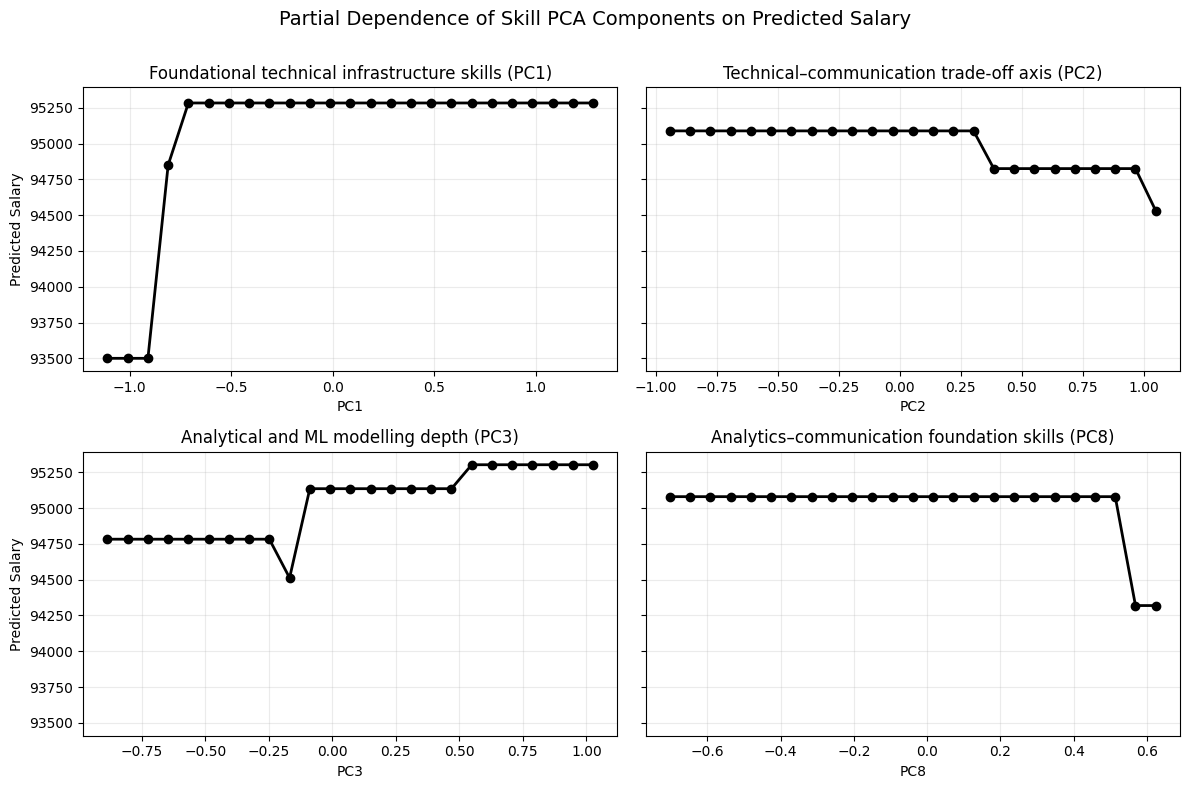

In [67]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize = (12,8), sharey=True)

axes[0,0].plot(pdp_df[pdp_df['feature'] == 'skill_PC1']['grid_value'], pdp_df[pdp_df['feature'] == 'skill_PC1']['pdp_mean_pred'],
               linewidth=2, marker="o", markersize=6, c = 'black')
axes[0,0].set_xlabel('PC1')
axes[0,0].set_ylabel('Predicted Salary')
axes[0,0].set_title('Foundational technical infrastructure skills (PC1)')

axes[0,1].plot(pdp_df[pdp_df['feature'] == 'skill_PC2']['grid_value'], pdp_df[pdp_df['feature'] == 'skill_PC2']['pdp_mean_pred'],
               linewidth=2, marker="o", markersize=6, c = 'black')
axes[0,1].set_xlabel('PC2')
axes[0,1].set_title('Technical–communication trade-off axis (PC2)')

axes[1,0].plot(pdp_df[pdp_df['feature'] == 'skill_PC3']['grid_value'], pdp_df[pdp_df['feature'] == 'skill_PC3']['pdp_mean_pred'],
               linewidth=2, marker="o", markersize=6, c = 'black')
axes[1,0].set_xlabel('PC3')
axes[1,0].set_ylabel('Predicted Salary')
axes[1,0].set_title('Analytical and ML modelling depth (PC3)')

axes[1,1].plot(pdp_df[pdp_df['feature'] == 'skill_PC8']['grid_value'], pdp_df[pdp_df['feature'] == 'skill_PC8']['pdp_mean_pred'],
               linewidth=2, marker="o", markersize=6, c = 'black')
axes[1,1].set_xlabel('PC8')
axes[1,1].set_title('Analytics–communication foundation skills (PC8)')

axes[0,0].grid(True, alpha=0.25)
axes[0,1].grid(True, alpha=0.25)
axes[1,0].grid(True, alpha=0.25)
axes[1,1].grid(True, alpha=0.25)

fig.suptitle(
    "Partial Dependence of Skill PCA Components on Predicted Salary\n",
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.savefig(OUT_DIR / "pdp_PC1_PC2_PC3_PC8.png", dpi=300, bbox_inches="tight")


##### Partial Dependence (PDP) — Skill PCA Components (PC1, PC2, PC3, PC8)

PDP curves were computed by fixing each skill PCA component to a sequence of values spanning the central 5th–95th percentile range, predicting salaries for the modified dataset, and averaging predictions across all observations. Across all four PCs, the curves are notably **piecewise-constant with sharp step changes**, which is expected for tree-based models (XGBoost) where predictions change primarily when feature values cross learned split thresholds.

- PC1 shows a clear **positive threshold effect**: predicted salary increases rapidly from low PC1 values and then **saturates**, indicating diminishing marginal returns beyond a moderate level of foundational technical infrastructure skill intensity. 
- PC2 exhibits an overall **negative association** over the evaluated range, with discrete downward steps suggesting that movement along this technical–communication trade-off axis shifts predictions into lower-paying regimes on average. 
- PC3 shows the most complex shape, including a local dip followed by stepwise increases and a plateau, consistent with a non-linear relationship where higher analytical/ML depth is rewarded after passing certain thresholds. 
- PC8 remains largely flat across most of its range and then drops sharply at the extreme upper end, suggesting that only very high values along this axis trigger a change in predicted salary, potentially reflecting interaction effects or a sparse region of the feature distribution.

Overall, PDPs here provide **shape diagnostics** rather than importance: they indicate where the model’s salary response to skill intensity changes (thresholds) and where additional increases yield little average gain (plateaus). These results should be interpreted as **model-implied marginal patterns** within observed data support, not as causal effects of acquiring specific skills.


## Block 4 — ICE (Individual Conditional Expectation)

### Objective
Assess **heterogeneity around PDP relationships** by examining how predicted salary responds to changes in selected skill PCA components **at the level of individual jobs**, rather than on average.

---

### Step-by-step workflow

1. **Confirm inputs**
   - Final trained Salary Response Model (same object used for SHAP and PDP).
   - Full model-ready feature matrix (`features`), with categorical variables preserved as `category` dtype.
   - Target features: `skill_PC1`, `skill_PC2`, `skill_PC3`, `skill_PC8`.
   - Reuse the same quantile-bounded grids defined for PDP (5th–95th percentile).

2. **Select a representative ICE sample**
   - Randomly sample a manageable subset of jobs (e.g. 200–500 rows) from the full feature matrix.
   - Fix a random seed to ensure reproducibility.
   - Purpose: visual clarity and computational efficiency, not inference.

3. **Generate ICE curves**
   For each target skill component:
   - For each sampled job \(i\):
     - Create a copy of that job’s feature vector.
     - Iterate over the grid values for the target component.
     - At each grid value \(v\), overwrite the target component with \(v\), leaving all other features unchanged.
     - Predict salary using the trained model.
   - Store the full set of predictions as individual response curves:
     `(feature, job_id, grid_value, predicted_salary)`.

4. **Overlay PDP reference**
   - Retrieve the previously computed PDP curve for the same feature.
   - Overlay the PDP (mean response) on top of the ICE curves for visual comparison.

5. **Visualisation**
   - Produce one plot per feature:
     - Many ICE curves plotted with high transparency (low alpha).
     - PDP curve plotted as a bold reference line.
   - Use consistent axes, scales, and formatting across features.
   - Save figures with filenames encoding feature name and analysis type.

6. **Quality control**
   - Verify that ICE curves show variability across jobs (unless the feature truly has no effect).
   - Confirm that the PDP curve lies within the envelope of ICE curves.
   - Inspect tails for instability; if present, narrow the grid range (e.g. 10th–90th percentile).

7. **Interpretation (strictly descriptive)**
   For each feature, document:
   - Degree of spread across ICE curves (low vs high heterogeneity).
   - Whether the direction of effect is consistent across jobs.
   - Whether the PDP curve is representative or averages over distinct regimes.
   - No causal language and no extrapolation beyond observed support.

8. **Documentation**
   - Add a concise ICE subsection to the Chapter 1 explainability documentation:
     - Brief methodology recap.
     - Summary of observed heterogeneity patterns.
     - Reference to saved figures.
   - Explicitly state that ICE diagnoses variability around PDP, not feature importance.

---

In [68]:
ice_cols = ['skill_PC1', 'skill_PC2', 'skill_PC3', 'skill_PC8']
ice_features = features
n_sample = 500

sampled_ice_features = ice_features.sample(
    n= n_sample,
    random_state=101
)

In [69]:
# Hyperparameters
q_low = 0.05
q_high = 0.95
grid_points = 25

# Grid building
lo = {}
hi = {}
grid = {}
for col in ice_cols:
    lo[col] = ice_features[col].quantile(q_low)
    hi[col] = ice_features[col].quantile(q_high)

    grid[col] = linspace(start=lo[col], stop=hi[col], num=grid_points)

In [70]:
results = []

for col in ice_cols:
    for v in grid[col]:

        # Baseline feature matrix
        X_tmp = sampled_ice_features.copy()

        # Fill the target feature with the grid value while maintaining all other features with their original values
        X_tmp[col] = v

        # Predict salary based on the grid value for that PC
        y_hat = salary_model.predict(X_tmp)

        # Save results
        for idx, pred in zip(sampled_ice_features.index, y_hat):
            results.append({
                    'feature':col,
                    'job_id':idx,
                    'grid_value':v,
                    'pred_salary':pred
            })
        
ice_df = pd.DataFrame(results)

# sanity check
len(ice_df) == n_sample * grid_points * len(ice_cols)

True

Individual Conditional Expectation (ICE) curves were computed to examine heterogeneity around the average effects observed in the PDP analysis. Using a random subsample of jobs, each target skill principal component was fixed to a sequence of values spanning its central empirical range, while all other job attributes were kept at their observed values. The trained Salary Response Model was then used to generate predictions for each job–grid combination, producing one prediction trajectory per job. Unlike PDPs, which average predictions across all observations at each grid value, ICE preserves job-level response paths, allowing inspection of how different job contexts respond differently to the same change in a skill dimension. This distinction makes ICE a diagnostic for interaction and heterogeneity, whereas PDP summarises the global average relationship.

In [71]:
ice_pdp = ice_df.merge(pdp_df, how = 'left', on = ('feature', 'grid_value'))
ice_pdp.head()

,feature,job_id,grid_value,pred_salary,pdp_mean_pred
0,skill_PC1,3003,-1.109813,142512.171875,93500.851562
1,skill_PC1,5766,-1.109813,67440.601562,93500.851562
2,skill_PC1,4546,-1.109813,98045.406250,93500.851562
3,skill_PC1,4496,-1.109813,91995.937500,93500.851562
4,skill_PC1,2599,-1.109813,93823.593750,93500.851562


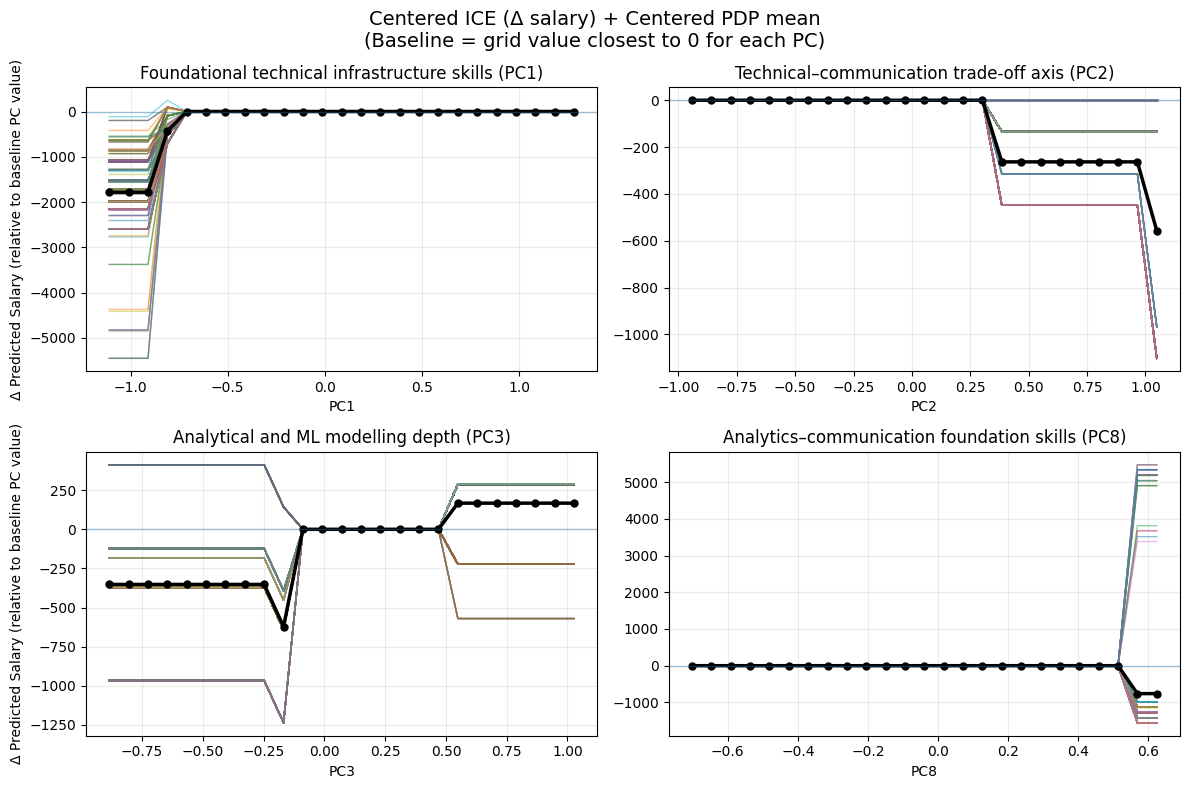

In [72]:
# ICE visual: CENTERED ICE (Δ salary) + PDP overlay (also centered)
# This removes baseline salary differences across jobs and makes the effect interpretable.

# ---- 1) Build a centered ICE dataframe (Δ relative to a baseline grid value per feature/job) ----
ice_plot = ice_pdp.copy()

# pick a baseline grid value per feature: the grid point closest to 0 (works well for PCA)
baseline_map = (
    ice_plot.groupby("feature")["grid_value"]
    .apply(lambda s: s.iloc[(s.abs()).argmin()])
    .to_dict()
)

# attach baseline grid value for each row
ice_plot["baseline_grid"] = ice_plot["feature"].map(baseline_map)

# compute baseline prediction per (feature, job_id) at that baseline grid point
baseline_pred = (
    ice_plot[ice_plot["grid_value"] == ice_plot["baseline_grid"]]
    .loc[:, ["feature", "job_id", "pred_salary"]]
    .rename(columns={"pred_salary": "baseline_pred_salary"})
)

# merge baseline back and compute delta
ice_plot = ice_plot.merge(baseline_pred, on=["feature", "job_id"], how="left")
ice_plot["delta_salary"] = ice_plot["pred_salary"] - ice_plot["baseline_pred_salary"]

# centered PDP line: subtract PDP value at baseline grid (one per feature)
pdp_baseline = (
    ice_plot[ice_plot["grid_value"] == ice_plot["baseline_grid"]]
    .drop_duplicates(subset=["feature", "grid_value"])
    .loc[:, ["feature", "pdp_mean_pred"]]
    .rename(columns={"pdp_mean_pred": "pdp_baseline_pred"})
)
ice_plot = ice_plot.merge(pdp_baseline, on="feature", how="left")
ice_plot["pdp_delta_salary"] = ice_plot["pdp_mean_pred"] - ice_plot["pdp_baseline_pred"]


# ---- 2) Plot: centered ICE spaghetti + centered PDP mean ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

panels = [
    ("skill_PC1", (0, 0), "PC1", "Foundational technical infrastructure skills (PC1)"),
    ("skill_PC2", (0, 1), "PC2", "Technical–communication trade-off axis (PC2)"),
    ("skill_PC3", (1, 0), "PC3", "Analytical and ML modelling depth (PC3)"),
    ("skill_PC8", (1, 1), "PC8", "Analytics–communication foundation skills (PC8)"),
]

for feat, (r, c), xlabel, title in panels:
    ax = axes[r, c]
    df = ice_plot[ice_plot["feature"] == feat].copy()
    df = df.sort_values(["job_id", "grid_value"])

    # ICE spaghetti (centered)
    for job_id, g in df.groupby("job_id"):
        ax.plot(
            g["grid_value"].values,
            g["delta_salary"].values,
            alpha=0.5,
            linewidth=1
        )

    # Centered PDP overlay
    pdp_curve = (
        df.drop_duplicates(subset=["grid_value"])
          .sort_values("grid_value")
    )
    ax.plot(
        pdp_curve["grid_value"].values,
        pdp_curve["pdp_delta_salary"].values,
        linewidth=2.5,
        marker="o",
        markersize=5,
        c="black"
    )

    ax.axhline(0, linewidth=1, alpha=0.4)  # reference line at no change
    ax.set_xlabel(xlabel)
    if c == 0:
        ax.set_ylabel("Δ Predicted Salary (relative to baseline PC value)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

fig.suptitle(
    "Centered ICE (Δ salary) + Centered PDP mean\n(Baseline = grid value closest to 0 for each PC)",
    fontsize=14,
    y=0.98
)

plt.tight_layout()


plt.savefig(OUT_DIR / "ice_centered_PC1_PC2_PC3_PC8.png", dpi=300, bbox_inches="tight")


Centered ICE curves were used to assess heterogeneity around the average partial dependence relationships identified by PDP. By expressing predictions as changes relative to a baseline skill level, the dominant variation due to job structure is removed, revealing the true marginal effect of each skill dimension. Across all four components, ICE trajectories are largely parallel and tightly clustered, indicating limited interaction-driven heterogeneity and confirming that PDP provides a faithful global summary. Skill_PC1 exhibits a clear gatekeeping pattern, with strong penalties at very low values and rapid saturation thereafter. Skill_PC2 and Skill_PC3 show discrete stepwise effects consistent with role-regime transitions rather than smooth marginal returns, while Skill_PC8 remains flat across most of its range, with instability only at extreme values near the edge of the empirical support. Overall, ICE confirms that skill effects in the model are stable, threshold-based, and secondary to structural job attributes.

# == End of Notebook ==